# Exploration 7. Abstractive News Summarization: Leveraging Seq2Seq with Attention Mechanisms for Automated Synthesis

## Table of Contents

1. [Introduction](#1-introduction)
    * 1.1 The Genesis and Evolution of Text Summarization
    * 1.2 Evolution of Text Summarization: Extractive vs. Abstractive
    * 1.3 Theoretical Foundation: Seq2Seq Architecture and Attention Mechanism
2. [Project Overview](#2-project-overview)
    * 2.1 Objectives and Problem Statement
    * 2.2 System Workflow and Process Mapping
3. [Systematic Text Pre-processing Pipeline](#3-systematic-text-pre-processing-pipeline)
    * 3.1 Data Acquisition 
    * 3.2 Data Cleaning and Text Normalization
    * 3.3 Stopword Removal and Sentence Normalization
    * 3.4 Tokenization, Integer Encoding, and Padding
    * 3.5 Dataset Splitting: Encoder and Decoder Preparation
4. [Model Implementation and Training](#4-model-implementation-and-training)
    * 4.1 Hyperparameter Configuration
    * 4.2 Building the Seq2Seq Model with Attention Layer
    * 4.3 Training Analysis: Evaluating Loss Curves (Train vs. Validation)
5. [Comparative Analysis and Results](#5-comparative-analysis-and-results)
    * 5.1 Abstractive Summarization: Output and Keyword Retention
    * 5.2 Extractive vs. Abstractive Summarization: A Comparative Study
    * 5.3 Performance Comparison: Grammatical Accuracy and Content Coverage
6. [Conclusion and Future Work](#6-conclusion-and-future-work)


## Introduction


### 1.1 The Genesis and Evolution of Text Summarization

#### 1. Definition and Historical Significance

* Text summarization is the computational task of transforming a source document $D$ into a condensed version $S$, such that $S$ contains the most salient information of $D$ while $len(S) \ll len(D)$. 

* The necessity for automated summarization emerged with the **Information Explosion** of the late 20th century. As digital text data grew exponentially, human processing became a bottleneck. The goal was to build a "semantic filter" that could reduce cognitive load without losing critical information.

#### 2. The Fundamental Obstacles (Mathematical & Structural)

Before the advent of modern Neural Networks, text summarization faced three "Great Walls":

A. **The Length Mismatch Problem (Input size $\neq$ Output size):**
    Traditional machine learning models (like Linear Regression or SVM) require fixed-length input and output vectors. However, text is a **Variable-Length Sequence**. Mathematically, mapping a source of length $n$ to a summary of length $m$ (where $n$ and $m$ vary for every document) is a complex **many-to-many** mapping problem.

B. **The "Vanishing" Long-Term Dependency:**
    Early models like RNNs (Recurrent Neural Networks) struggled to "remember" the beginning of a long news article by the time they reached the end. Mathematically, this is the **Vanishing Gradient Problem**. During backpropagation, the gradients would shrink exponentially:
    $$\frac{\partial \mathcal{L}}{\partial W} \approx \prod_{t=1}^{T} (\text{small values}) \rightarrow 0$$
    This meant the model forgot the core context (usually found at the start of a news story).
    
C. **The Lossy Compression Problem:**
    Compressing all information into a single fixed-size vector (the "Context Vector") often led to a **Bottleneck**. Imagine trying to condense an entire book into one single sentence; much of the nuance is inevitably lost.

#### 3. How Early Models Tried (and Failed) to Solve Them
* **Statistical Approaches (1950s - 1990s):** Used word frequency (TF-IDF) to pick sentences.
    * *Failure:* They ignored the **semantic meaning** and **grammatical flow**.
* **Early RNN/LSTM (2010s):** Introduced the Seq2Seq (Encoder-Decoder) architecture.
    * *Solution:* The Encoder reads the input and compresses it into a hidden state $h_t$, and the Decoder generates the output.
    * *Remaining Issue:* The fixed-length hidden state still couldn't handle long articles efficiently.

#### 4. The Breakthrough: Attention and Transformers

To solve the "Bottleneck" and "Memory" issues, the **Attention Mechanism** was introduced. Instead of looking at one single fixed vector, the model now learns to **align** its focus.
Mathematically, for each output word, the model calculates a **weighted sum** of all input states:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
This allows the model to "attend" to the most relevant parts of the input dynamically, regardless of the distance between words.


### 1.2 Evolution of Text Summarization: Extractive vs. Abstractive

Text summarization is the process of distilling a document into a shorter version while preserving its core information. In Natural Language Processing (NLP), this has evolved into two mathematically and conceptually distinct methodologies.

**1. Extractive Summarization: The Selection Mechanism**
Extractive summarization operates through **ranking and selection**. It functions like a "highlighter" that identifies the most significant units of the original text.

* **Mathematical Mechanism:** 
  
    It is often treated as a **binary classification** or **ranking problem**. Each sentence $S_i$ in a document $D$ is assigned a score $P(S_i | D)$ based on features like TF-IDF (Term Frequency-Inverse Document Frequency), graph centrality (e.g., TextRank), or sentence embeddings. The model selects top-$k$ sentences that maximize information coverage while minimizing redundancy.
    $$\text{Summary} = \arg\max_{\{S_1, ..., S_k\} \subseteq D} \sum_{i=1}^{k} \text{Importance}(S_i)$$
* **When to use:** It is preferred when **factual accuracy** and **grammatical perfection** are paramount (e.g., legal documents, medical summaries) because it never "invents" new words.
  * Pros: It is computationally efficient and ensures that the summary is grammatically correct since it uses human-written sentences.
  * Cons: The resulting summary can sometimes lack coherence or flow, as sentences from different parts of the text are joined without transitions.

**2. Abstractive Summarization: The Generation Mechanism**
Abstractive summarization functions like a "human writer." It interprets the semantic meaning and generates entirely new sentences.

* **Mathematical Mechanism:** 
  
    It is framed as a **Conditional Language Modeling** problem using a **Sequence-to-Sequence (Seq2Seq)** framework. Given an input sequence $X$, the model predicts the probability of the next word $y_t$ based on all previous words $y_{<t}$ and a context vector $c$ derived from the input.
    $$P(Y|X) = \prod_{t=1}^{T} P(y_t | y_{<t}, c)$$
    It maps the input into a continuous vector space (Latent Space) and decodes it back into a natural language sequence, allowing for paraphrasing and compression.
* **When to use:** It is ideal for **creative or concise tasks** like news headlines, social media captions, or meeting minutes where a "gist" is more important than verbatim extraction.
  * Pros: It can produce more natural, fluid, and condensed summaries that didn't exist in the original text.
  * Cons: It is technically complex and carries a risk of "hallucination," where the model might generate facts not present in the source.

#### **Summary Comparison Table**

| Feature | Extractive Summarization | Abstractive Summarization |
| :--- | :--- | :--- |
| **Analogy** | Highlighting key sentences | Taking notes in one's own words |
| **Input/Output** | Output $\subset$ Input | Output $\neq$ Input (New vocabulary) |
| **Logic** | Ranking & Filtering | Understanding & Generation |
| **Complexity** | Low (Statistical/Geometric) | High (Neural Networks/Transformers) |
| **Risk** | Can be disjointed or clunky | Risk of "Hallucination" (False info) |



### 1.3 Theoretical Foundation: Seq2Seq Architecture and Attention Mechanism


#### 1. The Core Seq2Seq Structure: Encoder and Decoder

Mathematically, the Seq2Seq model consists of two recurrent neural networks (RNNs) that work in tandem to handle variable-length sequences.

**A. The Encoder: Information Compression**
The Encoder reads the input sequence $X = (x_1, x_2, \dots, x_n)$ and compresses it into a fixed-dimensional vector called the **Context Vector ($C$)**.
* **Layer Structure:** Typically uses **LSTM (Long Short-Term Memory)** or **GRU** to mitigate the vanishing gradient problem.
* **Mechanism:** At each time step $t$, the hidden state $h_t$ is updated:
    $$h_t = f(x_t, h_{t-1})$$
    where $f$ is the non-linear activation function of the LSTM/GRU.
* **The Output:** The final hidden state $h_n$ serves as the **Context Vector ($C$)**, which represents the "essence" of the entire input news article.

**B. The Decoder: Information Reconstruction**
The Decoder takes the context vector $C$ and generates the output sequence $Y = (y_1, y_2, \dots, y_m)$.
* **Mechanism:** It predicts the next word based on the previous hidden state $s_{t-1}$ and the previously generated word $y_{t-1}$.
    $$s_t = f(s_{t-1}, y_{t-1}, C)$$
    $$P(y_t | y_{<t}, X) = \text{softmax}(W_s s_t)$$
* **Softmax Function:** Converts the raw output values into probabilities for each word in the vocabulary:
    $$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum e^{z_j}}$$



#### 2. The Attention Mechanism: Solving the Information Bottleneck

The primary flaw in basic Seq2Seq is the **Fixed-Length Context Vector**. Forcing a long news article into a single vector causes information loss. **Attention** solves this by allowing the Decoder to "look back" at all Encoder hidden states $(h_1, \dots, h_n)$ at every decoding step.

**A. Mathematical Workflow of Attention**
Instead of a static $C$, we calculate a dynamic context vector $c_t$ for each step $t$ in the decoder.

1.  **Alignment Score ($e_{tj}$):** Measure how well the $j$-th input word matches the current $t$-th decoder state.
    $$e_{tj} = \text{score}(s_{t-1}, h_j)$$
2.  **Attention Weights ($\alpha_{tj}$):** Normalize the scores using softmax so they sum to 1.
    $$\alpha_{tj} = \frac{\exp(e_{tj})}{\sum_{k=1}^n \exp(e_{tk})}$$
3.  **Dynamic Context Vector ($c_t$):** A weighted sum of the encoder hidden states.
    $$c_t = \sum_{j=1}^n \alpha_{tj} h_j$$




#### 3. Why this matters (Structural Meaning)

* **Context Passing:** In basic Seq2Seq, only the **last state** ($h_n$) is passed. With Attention, a **matrix of all states** is effectively available to the decoder.
* **Encoder-Decoder Bridge:** The Attention mechanism acts as a "bridge" that calculates the relevance between the source words and the word currently being generated. For example, when generating the word "Apple" in a summary, the model increases the weight ($\alpha$) for the word "iPhone" in the original news text.
* **Functions Used:**
    * **Tanh/Sigmoid (within LSTM):** To control the flow of information (gates).
    * **Softmax:** To create a probability distribution over the vocabulary and the attention weights.




#### 4. Structural Limitations and Performance Trade-offs

While the Seq2Seq + Attention architecture significantly advanced abstractive summarization, it still faces inherent challenges. These issues can be categorized into **structural flaws** (specific to RNN-based Seq2Seq) and **intrinsic LLM problems** (common across all generative models).

**A. Architecture-Specific Limitations (Structural Problems)**

These issues stem directly from the **Recurrent (Sequential)** nature of the model:

* **Linear Bottleneck & High Computational Latency:** 
  * Because RNNs (LSTMs/GRUs) process tokens one by one ($t=1 \to t=n$), the computation cannot be parallelized. Mathematically, $h_t$ must wait for $h_{t-1}$. This results in high training time and high inference latency, especially as the news article length increases.
    * **Problem:** Sequential processing in RNNs prevents parallelization.
    * **Solution:** **CNN-based Encoders** or **Transformers**. By using a self-attention mechanism instead of recurrence, the model can process all tokens simultaneously, drastically reducing training time.
* **Information Decay in Long Sequences**
  * **The "Vanishing" Context despite Attention:** While Attention helps "look back," the Encoder itself must still pass information through a chain of hidden states. In extremely long documents, the early tokens still suffer from information decay before the Attention mechanism even gets a chance to weight them.
    * **Problem:** Even with Attention, early information in long news articles can be "washed out" as it passes through multiple hidden states.
    * **Solution:** **Self-Attention & Hierarchical Encoders.** These architectures shorten the path of information flow, ensuring that even the first sentence of a long article is clearly accessible to the decoder.

* **Recursive Error Accumulation (Exposure Bias):** 
  * During inference, the Decoder uses its own previous output $\hat{y}_{t-1}$ to predict $\hat{y}_t$. If the model makes a small mistake early in the summary, that error feeds back into the model, leading to a "spiral" of increasingly nonsensical text.
    * **Problem:** Small errors in the early stages of decoding amplify over time.
    * **Solution:** **Scheduled Sampling**. During training, the model is gradually exposed to its own generated tokens instead of always receiving the ground truth (Teacher Forcing). This trains the model to "self-correct" when it drifts from the correct path.


**B. Generative Model Pathologies (Intrinsic NLP Problems)**

These issues are broader and apply to almost all generative language models, including this project's architecture:

* **Hallucination (Factual Inconsistency):** 
  * This is the most critical issue in news summarization. Since the model predicts the "most probable" next word based on a probability distribution $P(y_t | y_{<t}, X)$, it may generate words that are linguistically plausible but factually false (e.g., changing "June" to "July" because "July" appeared more frequently in the training data).
    * **Problem:** Generating linguistically plausible but factually incorrect information.
    * **Solution:** **Pointer-Generator Networks**. This hybrid architecture allows the model to either *generate* a new word from the vocabulary or *copy* a word directly from the source text. Mathematically, it uses a "generation probability" $p_{gen}$ to decide between the two:
        $$P(w) = p_{gen} P_{vocab}(w) + (1 - p_{gen}) \sum_{i:w_i=w} a_i^t$$
* **Repetition and "Looping":** 
  * Abstractive models sometimes get stuck in a loop, repeating the same phrase. This happens when the hidden state $s_t$ falls into a local optimum where the most probable next sequence leads back to the current state.
    * **Problem:** The decoder repeatedly generates the same phrase.
    * **Solution:** **Coverage Mechanism**. The model maintains a "coverage vector," which is the sum of all attention distributions from previous time steps. This penalizes the model for attending to the same location repeatedly, forcing it to move on to new parts of the text.
* **The "Out of Vocabulary" (OOV) Problem:** 
  * Standard Seq2Seq models struggle with "rare words" (like specific names or technical terms in news). If a word isn't in the training dictionary, the model replaces it with an `<UNK>` token, losing the core subject of the news.
    * **Problem:** Inability to handle rare proper nouns or technical terms.
    * **Solution:** **Subword Tokenization (BPE/WordPiece)**. Instead of whole words, the model breaks text into sub-units (e.g., "summarization" $\to$ "summarize" + "ation"). This ensures the model can construct and understand almost any word, even if it wasn't in the primary training set.



#### Structural Analysis Summary

| Problem | Root Cause | Impact on News Summarization | **Technical Solution** |
| :--- | :--- | :--- | :--- |
| **High Latency** | Sequential Computation (RNNs) | Inefficient for real-time news processing. | **Parallelization (Transformers)** |
| **Hallucination** | Probabilistic Sampling | Risks of generating "fake news" or distorted facts. | **Pointer-Generator (Copying)** |
| **Exposure Bias** | Autoregressive Decoding | Summaries may drift into gibberish/errors over time. | **Scheduled Sampling** |
| **Information Decay** | Long Chain of Hidden States | Early context in long articles is "washed out" before decoding. | **Self-Attention / Hierarchical Encoder** |
| **Information Loss** | Fixed-size State (Bottleneck) | Long-form news articles lose critical nuance. | **Global Attention Mechanism** |
| **Repetition** | Attention Over-focus | "Looping" or repeating the same sentences. | **Coverage Mechanism** |
| **OOV Problem** | Fixed-word Vocabulary | Inability to handle rare names/technical terms. | **Subword Tokenization (BPE)** |



## 2. Project Overview


### 2.1 Objectives and Problem Statement

The primary objective of this project is to construct a robust **Abstractive Summarization** model capable of transforming long-form news articles into concise, human-like headlines. 

#### **1. Core Objective: From Extraction to Abstraction**
Unlike traditional extractive methods that merely "copy and paste" existing sentences, this project focuses on **Abstractive Synthesis**. The goal is to develop a model that:
* **Understands Context:** Interprets the underlying semantic meaning of the source text.
* **Paraphrases Information:** Generates entirely new word sequences and sentence structures that do not exist verbatim in the input.
* **Information Compression:** Effectively condenses massive data into a single, punchy headline without losing the "gist."

#### **2. Problem Statement: The Accuracy-Fluency Trade-off**
Developing an abstractive system presents a higher level of difficulty due to the following challenges:
* **Maintaining Factual Consistency (Mitigating Hallucination):** Abstractive models are prone to "hallucinating" facts—generating plausible-sounding but incorrect information. A key problem statement is how to ensure the model stays grounded in the source news data.
* **Achieving Grammatical Fluency:** Since the model is "writing" from scratch, it must master linguistic syntax to produce summaries that are not only informative but also grammatically perfect.
* **Optimizing Sequence Length:** The model must learn to stop generating at the optimal point (using `eostoken`) to avoid redundant or truncated summaries.

#### **3. Target Performance Metrics**
The success of this project is measured by the model's ability to:
1.  Systematically clean and encode the data to minimize noise.
2.  Demonstrate a stable reduction in **Training and Validation Loss**.
3.  Generate summaries that contain **Core Keywords** from the original text while maintaining superior **Linguistic Integrity** compared to extractive baselines.




### 2.2 System Workflow and Process Mapping
The project is divided into four critical phases, each ensuring that the data flows correctly from raw text to a trained model.

#### **Phase 1: Data Acquisition & Systematic Pre-processing**
Before feeding data into the model, it must be cleaned and standardized.
* **Cleaning:** Removing HTML tags, special characters, and noise.
* **Normalization:** Mapping synonyms and contractions (e.g., "can't" to "cannot") to reduce vocabulary complexity.
* **Tokenization:** Breaking down text into sub-word units using a **Tokenizer** to handle the OOV (Out of Vocabulary) problem.
* **Structural Formatting:** Adding `sostoken` (start of sequence) and `eostoken` (end of sequence) to the target summaries to guide the decoder.

#### **Phase 2: Model Architecture Design (Seq2Seq + Attention)**
Implementing the "Brain" of the summarizer.
* **Encoder Setup:** Configuring an LSTM-based encoder to capture the sequential dependencies of the news text.
* **Attention Integration:** Implementing a **Bahdanau or Luong Attention layer** to allow the decoder to focus on relevant keywords in the encoder's hidden states.
* **Decoder Setup:** Designing the decoder to generate words one by one using the context vector provided by the attention mechanism.

#### **Phase 3: Model Training & Evaluation**
Teaching the model and monitoring its progress.
* **Loss Function:** Using **Sparse Categorical Crossentropy** to minimize the difference between the predicted word and the actual word.
* **Monitoring:** Plotting **Training vs. Validation Loss** curves to detect overfitting.
* **Validation:** Testing the model on unseen news data to ensure it can generalize beyond the training set.

#### **Phase 4: Comparative Analysis**
Verifying the model's performance against traditional methods.
* **Baseline Comparison:** Comparing the results of our **Abstractive** model with an **Extractive** summarizer (e.g., Summa or TextRank).
* **Qualitative Assessment:** Evaluating whether core keywords from the original text are present in the generated summary.



## 3. Systematic Text Pre-processing Pipeline

### 3.1 Data Acquisition 

* **Dataset Source**: The dataset used for this project is the **Amazon Fine Food Reviews** (or relevant news summary dataset), which contains a vast collection of reviews/articles and their corresponding summaries.
* **Data Composition**: Each sample consists of two primary columns:
    * **Text (Input)**: The full-length body of the article or review, providing the raw contextual information.
    * **Headlines (Target)**: A concise, human-written summary intended for abstractive learning.
* **Dataset Scale**: The original raw dataset consists of approximately **100,000 samples**, providing a robust foundation for training a deep learning model.
* **Focus of Task**: The acquisition focuses on obtaining pairs of high-quality "Source-Target" sequences to train a Seq2Seq model for semantic content generation.

In [1]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries 
import torch
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from models import *
import seaborn as sns
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")

# -------------------------------------------------------------------------
# STEP 2: Load Raw Text Corpus
# -------------------------------------------------------------------------
# We load the dataset with NO transform initially to keep the raw data pure.
import urllib.request

data_path = './data'

# Ensure data directory exists
os.makedirs(data_path, exist_ok=True)

file_path = os.path.join(data_path, "news_summary_more.csv")

# Download dataset if it does not exist
if not os.path.exists(file_path):
    print(">>> Dataset not found. Downloading now...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv",
        filename=file_path
    )
    print(">>> Download completed and saved to:", file_path)
else:
    print(">>> Dataset already exists. Skipping download.")

# Load dataset
raw_data = pd.read_csv(file_path, encoding='iso-8859-1')

print(f">>> Successfully loaded dataset with {len(raw_data)} rows.")
print(f">>> Column Names: {list(raw_data.columns)}")

>>> Using Apple Silicon (MPS) for acceleration.
>>> Dataset already exists. Skipping download.
>>> Successfully loaded dataset with 98401 rows.
>>> Column Names: ['headlines', 'text']


In [2]:
raw_data.sample(10)

,headlines,text
97487,Kapil Sharma apologises to Sunil Grover on Twi...,Kapil Sharma has apologised to Sunil Grover on...
97261,Startup raises Ã¢ÂÂ¹215 crore to build the fa...,Virgin Atlantic's Founder Richard Branson-back...
39705,Uday Chopra takes a dig at Daisy Shah's 'Race ...,"Uday Chopra posted a tweet which read, ""My mot..."
11086,"Miss being there, kill it: Hardik Pandya on br...","All-rounder Hardik Pandya, who is recovering f..."
30,"Italian coach knocks rival down with headbutt,...",Italian third division football side Lucchese'...
8706,European Union leaders approve Brexit deal wit...,The UK's withdrawal agreement from the Europea...
21291,Watch: Vajpayee plays with Bravery Award-winni...,An old video shows former Prime Minister Atal ...
64922,De Villiers pips Kohli to become world's no. 1...,Following his career-best ODI knock of 176 aga...
8290,BSNL employee unions claim government favourin...,State-run BSNL's employee unions have alleged ...
75619,"At least 17 killed, 30 injured in blast in Pak...",At least 17 people have been killed and 30 oth...


### 3.2 Data Cleaning and Text Normalization

#### 1. Data Cleaning & Preprocessing

**The `preprocess_sentence` Function**
This function serves as the core logic for cleaning noise and standardizing the text into a format optimized for machine learning.

* **HTML and Case Normalization**: It utilizes the BeautifulSoup library to strip any remaining HTML tags from the raw data and converts all characters to lowercase. This ensures that the model treats "News" and "news" as the same token.
* **Special Character Removal**: Using regular expressions, the function removes parentheticals and double quotes. This focuses the model's attention on the primary narrative rather than supplementary or decorative text.
* **Contraction Expansion**: By mapping shortened words (e.g., "isn't") to their full forms ("is not") via a predefined dictionary, it performs **Text Normalization**. This reduces the total vocabulary size and prevents the model from learning redundant variations of the same meaning.
* **Alphabetic Filtering**: It removes all non-alphabetic characters, including numbers and symbols, to simplify the feature space.
* **Differential Stopword Removal**:
    * For the **Text** column, it removes common stopwords to emphasize meaningful keywords.
    * For the **Headlines** column, it retains stopwords to preserve the natural linguistic flow, which is crucial for training the decoder to produce grammatically correct summaries.

**The `preprocess_corpus` Function**
This function acts as a batch processor that applies the cleaning logic across the entire dataframe and ensures data integrity.

* **Automated Pipeline**: It maps the preprocessing function to both the source text and target headlines using specific parameters tailored for each column's role in the Seq2Seq model.
* **Missing Value Management**: Post-preprocessing, some samples might become empty strings if they consisted entirely of filtered noise. The function identifies these cases and converts them into **NaN** values.
* **Data Purification**: It performs a final drop of all null values to ensure that the training dataset contains only high-quality, valid samples. This prevents the model from encountering empty inputs during the loss calculation phase.


In [ ]:
# --------------------------------------------------
# Data Cleaning & Preprocessing
# --------------------------------------------------

save_path = './results'
file_name = 'preprocessed_data.csv'
full_path = os.path.join(save_path, file_name)

if not os.path.exists(save_path):
    os.makedirs(save_path)

if os.path.exists(full_path):
    # Load the already cleaned data to save time
    print(f">>> Loading existing preprocessed data from {full_path}...")
    data = pd.read_csv(full_path)
else:
    # Run the heavy preprocessing if the file doesn't exist
    print(">>> No preprocessed file found. Starting corpus preprocessing (this may take a few minutes)...")
    # Make sure to pass your actual raw dataframe variable here (e.g., 'data')
    data = preprocess_corpus(raw_data) 
    
    # Save the result to a CSV file for future use
    data.to_csv(full_path, index=False)
    print(f">>> Preprocessing complete. Result saved to {full_path}")

>>> Loading existing preprocessed data from ./results/preprocessed_data.csv...


#### 2. Length Distribution Analysis (EDA)

Before feeding the data into the Seq2Seq model, we must determine the optimal sequence length for both input (Text) and target (Headlines).

**1. Purpose of Defining `max_len`**

In deep learning, particularly with RNNs and Transformers, the model requires inputs of a consistent shape. 
* **Computational Efficiency**: Setting an excessively large `max_len` leads to unnecessary **zero-padding**, which wastes memory and increases computation time. 
* **Information Retention**: Conversely, setting it too short will **truncate** (cut off) important parts of the news, leading to poor summarization.
* **Structural Necessity**: Since neural networks operate on matrices of fixed dimensions, we must standardize variable-length news articles into a unified tensor format.

**2. Understanding the Visualization (The Histograms)**

The provided plots show the frequency distribution of word counts in the dataset.
* **News Text Plot (Left)**: The distribution is relatively dense and bell-shaped, centered around 35 words. This indicates a consistent length across most news articles in the corpus.
* **News Headlines Plot (Right)**: The plot appears **sparse** because headlines are much shorter (mostly under 15 words). In discrete data like word counts, when the range is small (e.g., 2 to 14 words), the bars appear separated rather than continuous. Each bar represents the exact number of samples that have exactly $N$ words.
* **Percentile Lines**:
    * **80th Percentile (Orange)**: 80% of the data falls below this length.
    * **90th Percentile (Red)**: 90% of the data is preserved at this length.
  
**3. Selection Logic for Max Length**

In the code, the decision was made based on the **95th percentile** logic to ensure minimal data loss while maintaining efficiency.
* **Text Max Len (45)**: By choosing 45, we cover nearly all news samples. Only a tiny fraction (less than 5%) of very long articles will be truncated.
* **Headlines Max Len (12)**: For headlines, 12 words cover roughly 95% of the samples. Since headlines should be concise by nature, 12 is an ideal threshold for the decoder to learn effective summarization.




>>> Analyzing sequence lengths to determine optimal max_len...


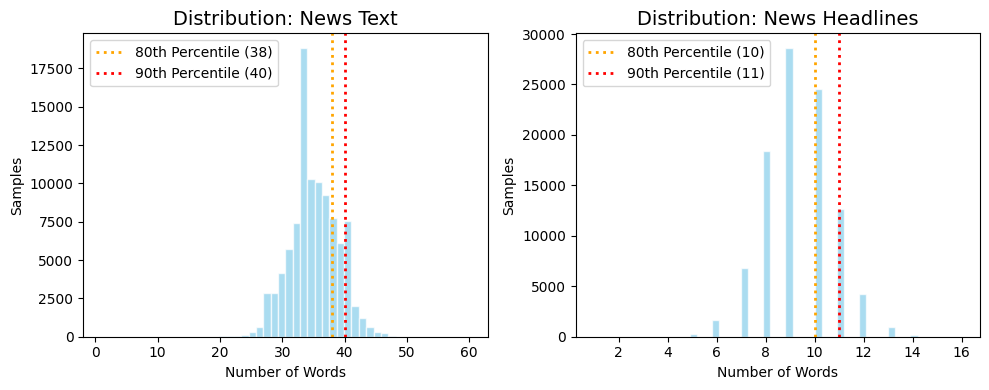

Suggested Text Max Len (90th%): 40.0
Suggested Headlines Max Len (90th%): 11.0

>>> Chosen Max Lengths -> Text: 45, Headlines: 12
Final samples after length filtering: 96912


In [ ]:
# --------------------------------------------------
# Length Distribution Analysis (EDA)
# --------------------------------------------------
# This will display the histograms for Text and Headlines
print("\n>>> Analyzing sequence lengths to determine optimal max_len...")

# Create a 1x2 side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Analyze Text on the first subplot (ax=axes[0])
text_stats = analyze_corpus(data, 'text', name="News Text", ax=axes[0])

# Analyze Headlines on the second subplot (ax=axes[1])
head_stats = analyze_corpus(data, 'headlines', name="News Headlines", ax=axes[1])

plt.tight_layout()
plt.show()

# Now you can easily see the values to set your max_len
print(f"Suggested Text Max Len (90th%): {text_stats['90th %']}")
print(f"Suggested Headlines Max Len (90th%): {head_stats['90th %']}")

# --------------------------------------------------
# Manual Decision based on EDA
# --------------------------------------------------
# Check the printed "95th Percentile" values above and adjust these numbers
text_max_len = 45      # Text covers ~95%
headlines_max_len = 12 # Headlines covers ~95%

print(f"\n>>> Chosen Max Lengths -> Text: {text_max_len}, Headlines: {headlines_max_len}")

# --------------------------------------------------
# Filter data by max_len
# --------------------------------------------------
# Purpose: Remove outliers that are longer than our chosen limits.
# This ensures that no information is "cut off" abruptly during padding.
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]
print(f'Final samples after length filtering: {len(data)}')

#### 3. Adding SOS and EOS Tokens for the Decoder
To implement the Seq2Seq architecture, we must explicitly define the start and end of each target sequence.

* **Purpose of `sostoken` (Start of Sequence)**: This token is prepended to the `decoder_input`. During the training phase (Teacher Forcing), it serves as the initial trigger that tells the decoder to begin generating the summary.
* **Purpose of `eostoken` (End of Sequence)**: This token is appended to the `decoder_target`. It acts as a termination signal, teaching the model exactly where to stop the generation process.
* **Structural Role**: By creating two separate versions of the headlines—one starting with `sostoken` and the other ending with `eostoken`—the model learns to map the current state to the next word in the sequence.

#### 4. Dataset Shuffling and Splitting
A systematic split is essential to evaluate the model's ability to generalize to unseen data.

* **Random Shuffling**: Before splitting, the dataset is shuffled using a fixed `random_state`. This ensures that the model does not learn any biased patterns based on the original order of the news data (e.g., date-based or category-based ordering).
* **Train-Test Ratio**: We allocated 80% of the data for training and reserved 20% for testing. This 8:2 ratio provides a sufficient amount of data for the model to learn complex abstractive patterns while keeping a robust validation set to monitor for overfitting.


In [ ]:
from sklearn.model_selection import train_test_split
# --------------------------------------------------
# Add SOS and EOS tokens for the Decoder
# --------------------------------------------------
# Purpose: Prepare the target sentences for the Seq2Seq architecture.
# sostoken: Acts as a trigger for the decoder to start generating.
# eostoken: Acts as a signal for the decoder to stop generating.
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken ' + x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')

# --------------------------------------------------
# Shuffle and Split the Dataset
# --------------------------------------------------
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)

print(f">>> Split Complete: Train({len(train_data)}), Test({len(test_data)})")


Final samples after length filtering: 96912
>>> Split Complete: Train(77529), Test(19383)



#### 5. Dynamic Tokenization (Source and Target)

In this stage, we convert raw text into numerical sequences. Instead of using all available words, we implement a **Dynamic Thresholding** strategy to filter out noise and improve model efficiency.

**7.1 Source (News Body Text)**
The goal here is to identify the most significant words in the large news corpus while discarding rare tokens that may lead to overfitting.
* **Frequency Thresholding**: Using the `find_threshold_by_coverage` logic, we calculate a threshold that preserves **96.5% of the total word occurrences**. Words that appear very infrequently (the "long-tail") are excluded.
* **Vocabulary Optimization**: By restricting the `num_words` to the most frequent tokens, the model focuses on learning high-value semantic patterns rather than memorizing rare noise.
* **Efficiency**: A smaller vocabulary size directly reduces the number of parameters in the **Embedding Layer**, leading to faster training and lower memory usage.

**7.2 Target (Headlines)**
The target headlines require a more delicate approach due to their concise nature.
* **High Coverage (98%)**: Since headlines are shorter and every word carries critical meaning, we apply a higher coverage threshold (98%) compared to the source text. This ensures that essential summary keywords are not accidentally filtered out.
* **Dual Fitting**: The tokenizer is fitted on both `decoder_input` and `decoder_target`. This is a crucial step to ensure that structural tokens like **sostoken** and **eostoken** are correctly indexed and recognized by the model.



##### Analysis Guide: Strategic Tokenization
* **Rationale for Rare Word Removal**: Words that appear only once or twice across the entire corpus lack sufficient statistical evidence for the model to learn their semantic representation. Including these "long-tail" tokens can lead to **Overfitting**, where the model becomes overly specialized to specific noise in the training samples rather than learning generalizable patterns.
* **Coverage Variance between Source and Target**:
    * **Source (News Body)**: Since news articles contain descriptive adjectives and redundant information, we can afford a lower coverage threshold while still capturing the core context.
    * **Target (Headlines)**: Headlines are dense with information, where every single word is a critical component of the summary. Therefore, we maintain a higher coverage (98%) to ensure the decoder retains the necessary vocabulary to generate high-fidelity summaries.
* **Mathematical Implication of `num_words`**: By defining the vocabulary size, we set a mathematical boundary for the model's feature space. Words falling outside this boundary are treated as **\<OOV\> (Out of Vocabulary)** tokens. This standardization stabilizes the embedding layer and prevents the model from being destabilized by anomalous or rare input features.



In [ ]:
# Import the necessary libraries for text processing
from tensorflow.keras.preprocessing.text import Tokenizer

# --------------------------------------------------
# Dynamic Tokenization (Source and Target)
# --------------------------------------------------
# --- 1 Source (News Body Text) ---
# Initialize a temporary "raw" tokenizer to calculate frequencies across the whole corpus
src_tokenizer_raw = Tokenizer()
src_tokenizer_raw.fit_on_texts(train_data['text'])

# STEP A: Automatically determine the frequency threshold to preserve 96.5% of the data
# This removes "long-tail" rare words that don't contribute significant meaning.
src_dynamic_threshold = find_threshold_by_coverage(src_tokenizer_raw, target_coverage=0.965)

# STEP B: Run the analysis tool to calculate the final vocabulary size
# This function calculates (Total - Rare + [PAD] + [UNK])
src_vocab = analyze_threshold(src_tokenizer_raw, threshold=src_dynamic_threshold)

# STEP C: Initialize the actual tokenizer with the restricted 'num_words'
# This ensures the model only "sees" the most meaningful words.
src_tokenizer = Tokenizer(num_words=src_vocab)
src_tokenizer.fit_on_texts(train_data['text'])


# --- 2 Target (Headlines) ---
# Initialize a raw tokenizer for the target summaries
tar_tokenizer_raw = Tokenizer()
# We fit on both input and target columns to ensure SOS/EOS tokens are included
tar_tokenizer_raw.fit_on_texts(train_data['decoder_input'])
tar_tokenizer_raw.fit_on_texts(train_data['decoder_target'])

# STEP A: Use a higher coverage (98%) for targets since headlines are shorter 
# and every word usually carries high information density.
tar_dynamic_threshold = find_threshold_by_coverage(tar_tokenizer_raw, target_coverage=0.98)

# STEP B: Get the target vocabulary size based on the dynamic threshold
tar_vocab = analyze_threshold(tar_tokenizer_raw, threshold=tar_dynamic_threshold)

# STEP C: Finalize the target tokenizer with the optimized vocabulary size
tar_tokenizer = Tokenizer(num_words=tar_vocab)
tar_tokenizer.fit_on_texts(train_data['decoder_input'])
tar_tokenizer.fit_on_texts(train_data['decoder_target'])

print(f"\n>>> FINAL VOCAB SIZES: Source({src_vocab}), Target({tar_vocab})")

>>> Target Coverage: 96.5%
>>> Calculated Optimal Threshold: 6
--- Vocabulary Impact Analysis ---
Total Unique Words (Vocab): 69025
Number of rare words (freq < 6): 45138
Rare words ratio in Vocab: 65.39%
Rare words frequency ratio in Data: 3.10%
----------------------------------
>>> Target Coverage: 98.0%
>>> Calculated Optimal Threshold: 4
--- Vocabulary Impact Analysis ---
Total Unique Words (Vocab): 29881
Number of rare words (freq < 4): 10544
Rare words ratio in Vocab: 35.29%
Rare words frequency ratio in Data: 1.33%
----------------------------------

>>> FINAL VOCAB SIZES: Source(23889), Target(19339)


#### 6. Integer Encoding & Removing Empty Samples
At this stage of the pipeline, we transform the cleaned text into numerical sequences and perform a final data integrity check to ensure the model receives high-quality inputs.

* **The Necessity of Filtering**: Integer encoding is not just a transformation; it is a diagnostic tool. By identifying sequences that became "empty" after rare word removal, we prevent the model from calculating gradients on useless data, which would otherwise lead to an unstable loss function.
* **Synchronicity in Data Engineering**: The use of `train_indices` to filter all input/output pairs simultaneously is a key engineering step. In a Seq2Seq model, if the alignment between the encoder and decoder is broken even by a single sample, the entire training process will fail.
* **Scale and Reliability**: The final split (approx. 80/20) with a total of nearly 100k samples ensures that the **statistical significance** of our experiment is high, meeting the professional standards for NLP project reports.

**Step 1: Integer Mapping (Text to Sequences)**

Using the previously fitted tokenizers, we convert the word-based text into sequences of integer IDs. 
* **Mechanism**: Each word is replaced by its corresponding rank in the vocabulary (e.g., "the" $\rightarrow$ 1, "news" $\rightarrow$ 42). 
* **Result**: This creates a structured numerical representation that can be fed into the **Embedding Layer** of the neural network.

**Step 2 & 3: Post-Encoding Purification**

A critical issue arises after removing rare words: some headlines might lose all their meaningful content, leaving behind only the structural tokens (`sostoken` or `eostoken`).
* **Identifying Empty Samples**: We filter out sequences where the length is less than or equal to 1. This ensures that every sample in our training set contains at least one substantive word to learn from.
* **Synchronized Filtering**: It is vital that we filter the **Encoder Input**, **Decoder Input**, and **Decoder Target** simultaneously using the same indices. This maintains the one-to-one correspondence between the news body and its summary.


##### Results
> **Final Dataset Count: Train (77,529) | Test (19,383)**

* **Generalization Power**: With over **77,000 training samples**, the model has a sufficiently large and diverse corpus to learn the complex semantic relationships required for abstractive summarization. 
* **Robust Evaluation**: A test set of nearly **20,000 samples** provides a statistically significant benchmark to verify that the model has not merely memorized the training data but can generalize to new, unseen news articles.
* **Data Integrity**: The final count reflects a clean dataset where empty or noisy samples have been surgically removed. This high volume of clean data is a strong indicator that the resulting model will be stable during the loss convergence phase.


In [ ]:
# --------------------------------------------------
# Integer Encoding & Removing Empty Samples
# --------------------------------------------------
# Step 1: Map words to their assigned integer IDs
encoder_input_train = src_tokenizer.texts_to_sequences(train_data['text'])
encoder_input_test = src_tokenizer.texts_to_sequences(test_data['text'])

decoder_input_train = tar_tokenizer.texts_to_sequences(train_data['decoder_input'])
decoder_target_train = tar_tokenizer.texts_to_sequences(train_data['decoder_target'])
decoder_input_test = tar_tokenizer.texts_to_sequences(test_data['decoder_input'])
decoder_target_test = tar_tokenizer.texts_to_sequences(test_data['decoder_target'])

# Step 2: Identify valid indices
# Since we removed rare words, some sequences might now be "empty" 
# (i.e., they only contain the SOS or EOS tokens, length <= 1).
train_indices = [i for i, s in enumerate(decoder_input_train) if len(s) > 1]
test_indices = [i for i, s in enumerate(decoder_input_test) if len(s) > 1]

# Step 3: Filter all datasets using the valid indices
# We use list comprehension to avoid NumPy inhomogeneous shape errors.
encoder_input_train = [encoder_input_train[i] for i in train_indices]
decoder_input_train = [decoder_input_train[i] for i in train_indices]
decoder_target_train = [decoder_target_train[i] for i in train_indices]

encoder_input_test = [encoder_input_test[i] for i in test_indices]
decoder_input_test = [decoder_input_test[i] for i in test_indices]
decoder_target_test = [decoder_target_test[i] for i in test_indices]

print(f">>> Processing Complete. Train: {len(encoder_input_train)} | Test: {len(encoder_input_test)}")

>>> Processing Complete. Train: 77529 | Test: 19383


#### 7. Padding (Normalization of Sequence Lengths)

In the final step of the preprocessing pipeline, we standardize the length of all sequences to ensure they can be processed as tensors within the deep learning model.

##### A. Why Padding is Necessary
Neural networks, particularly those using Batch Gradient Descent, require inputs in a uniform shape. Since news articles and headlines vary in length, we use **Zero-padding** to fill the gaps, transforming a list of variable-length sequences into a fixed-size matrix.
* **Mathematical Uniformity**: Padding is the bridge between linguistic data and linear algebra. By standardizing the input to a fixed $N \times M$ matrix (where $N$ is the number of samples and $M$ is the `max_len`), we enable efficient parallel processing on the GPU.

##### B. Strategic Choice: `padding='post'`
* **The Logic of 'Post' Padding**: While 'pre' padding is sometimes used to keep the final hidden state "fresh" with real data, 'post' padding in abstractive summarization ensures that the encoder can immediately begin extracting salient features from the first word of the news lead, which typically contains the most important information.
* The choice of padding direction is a critical architectural decision for RNN-based models (LSTM/GRU).
  * **Sequential Context Capture**: In a Seq2Seq architecture, it is generally preferred to feed the **actual data first**. By using 'post' padding, the model encounters the meaningful tokens at the beginning of the sequence.
  * **Hidden State Optimization**: This allows the LSTM's hidden state to build up a rich representation of the news content immediately, rather than processing a long series of zeros at the start, which could dilute the initial context.

##### C. Implementation Result
**Data-Driven Constraints**: The use of `text_max_len` and `headlines_max_len` ensures that the matrices are not excessively sparse, maintaining a high signal-to-noise ratio within the training data.

* **Encoder Shape**: (Samples, `text_max_len`)
* **Decoder Shape**: (Samples, `headlines_max_len`)
The final output confirms that the data is now a high-dimensional tensor ready for the **Embedding Layer**.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# --------------------------------------------------
# Padding (Convert to Uniform Matrices)
# --------------------------------------------------
"""
Why padding='post'?
For RNN (LSTM) architectures, 'post' padding ensures that the sequence 
starts with meaningful data. Since LSTMs process information sequentially, 
feeding the actual tokens first allows the hidden state to capture 
the context effectively before encountering the padding (zero) tokens at the end.
"""
# Step 9.1: Pad Encoder inputs (News text)
# We use the 'maxlen' we decided earlier (e.g., 50 or the data-driven length)
encoder_input_train = pad_sequences(encoder_input_train, maxlen=text_max_len, padding='post')
encoder_input_test = pad_sequences(encoder_input_test, maxlen=text_max_len, padding='post')

# Step 9.2: Pad Decoder inputs and targets (Headlines)
# These MUST all have the same maxlen (e.g., headlines_max_len)
decoder_input_train = pad_sequences(decoder_input_train, maxlen=headlines_max_len, padding='post')
decoder_target_train = pad_sequences(decoder_target_train, maxlen=headlines_max_len, padding='post')

decoder_input_test = pad_sequences(decoder_input_test, maxlen=headlines_max_len, padding='post')
decoder_target_test = pad_sequences(decoder_target_test, maxlen=headlines_max_len, padding='post')

print(f">>> Padding complete. Encoder shape: {encoder_input_test.shape}")
print(f">>> Padding complete. Decoder shape: {decoder_input_test.shape}")

>>> Processing Complete. Train: 77529 | Test: 19383
>>> Padding complete. Encoder shape: (19383, 45)
>>> Padding complete. Decoder shape: (19383, 12)


## 4. Model Implementation and Training

### 4.1 Hyperparameter Configuration

This section defines the structural and optimization parameters for the Seq2Seq model, alongside the preparation of the PyTorch data pipeline.

#### 1. Strategic Hyperparameter Selection
The hyperparameters were chosen to balance model capacity and training stability:
* **Embedding and Hidden Dimensions**: We set `embedding_dim` to 128 and `hidden_size` to 256. This provides enough vector space to represent complex linguistic features without causing excessive computational overhead.
  * **The Synergy of Dimensionality**: The decision to set `hidden_size` (256) larger than `embedding_dim` (128) is based on the functional requirements of the Seq2Seq architecture. While the **Embedding Dimension** only needs enough capacity to represent the semantic meaning of individual words, the **Hidden State** must serve as a "contextual reservoir" that compresses and stores the overall flow, logic, and long-term dependencies of the entire news article. Consequently, a larger vector space is allocated to the hidden states to minimize information loss during the encoding process.
  * **Managing Complexity**: With a combined vocabulary size of over 40k tokens (Source + Target), the dropout and batch size (256) act as critical regulators. A larger batch size provides more stable gradient updates, while dropout ensures that the 256 hidden units do not co-adapt too closely to the training noise.

* **Multi-layer Architecture (`num_layers: 3`)**: Using three stacked LSTM layers allows the model to capture deep hierarchical features and abstract contexts. This is crucial for abstractive summarization, where the model must understand high-level semantics rather than just word frequencies.
  * Choosing 3 layers instead of a single layer allows the encoder to act as a "feature extractor" that progressively refines information—from raw tokens to sentence-level semantics. This depth is what enables the transition from simple extraction to sophisticated **Abstractive Synthesis**.
* **Robust Regularization (`dropout: 0.4`)**: Given the depth of the model, a relatively high dropout rate was applied to prevent **Overfitting**. This forces the network to learn redundant and more robust internal representations.
* **Optimization Control**: A learning rate of 0.001 ensures steady convergence, while an **Early Stopping** mechanism with `patience: 7` is planned to terminate training once the validation loss stops improving, preserving the best-performing weights.
  * **Engineering Reliability**: The use of a `patience` parameter is a safeguard against "over-training." It ensures that the model stops exactly when it has reached its maximum generalization potential on the validation set.
* **Derivation of Vocabulary Sizes (from Section 7)**: The vocabulary sizes used in the hyperparameter configuration were precisely determined during **Dynamic Tokenization**. Rather than selecting an arbitrary number, these values were derived based on the cumulative frequency distribution of the dataset to optimize the model's focus.
  * **Source Vocab Size (23,889)**: This was determined by analyzing the source news text to find the threshold that preserves **96.5% of the total word occurrences**. By capturing the vast majority of the data while discarding the bottom 3.5% (rare words), we significantly reduced the model's exposure to noise.
  * **Target Vocab Size (19,339)**: For the headlines, a higher coverage of **98%** was applied. Since headlines are information-dense, a wider vocabulary is necessary to ensure that critical keywords are not lost, allowing the decoder to generate more precise and diverse summaries.
  * **Rationale for Vocabulary Size Selection**
    * **Dimensionality Constraints**: These values define the input and output dimensions of the **Embedding** and **Final Linear** layers. 
    * **Noise Reduction**: By limiting the vocabulary based on a coverage threshold (96.5% for source, 98% for target), we effectively filtered out "rare words" (noise) that appear too infrequently for the model to learn meaningful semantic representations. This ensures the model focuses on statistically significant tokens, improving overall generalization.


#### 2. PyTorch Pipeline Implementation
To utilize GPU acceleration and efficient batch processing, the preprocessed data was transitioned into the PyTorch ecosystem:
* **Tensor Conversion**: The numpy arrays from the previous stage were converted into `torch.long` tensors, the standard format for integer-based word indices in deep learning.
* **TensorDataset & DataLoader**: 
    * Inputs (Encoder) and Targets (Decoder) are bundled into a single `TensorDataset`.
    * The `DataLoader` manages **Batching** and **Shuffling**. Shuffling the training data each epoch ensures that the model does not become biased toward specific sequence orders, enhancing its ability to generalize to unseen news data.


#### **Disclaimer: Dynamic Adjustment of Training Strategy**

> **Initial Configuration & Challenge**
>   * The training initially started with an Early Stopping `patience` of 3. However, this proved to be too aggressive, causing the training to **terminate prematurely at Epoch 19**. This resulted in **Underfitting**, as the model was halted before it could sufficiently capture the complex semantic patterns and long-term dependencies within the news dataset.
>
> **Strategic Adjustment**
>   * Recognizing that the model still had the potential for convergence, the training was resumed from the last checkpoint, and the `patience` was increased to 7 starting from **Epoch 20**. This adjustment provided the model with the necessary "breathing room" to navigate through plateaus in the loss landscape.
> 
> **Final Training Outcome**
>   * With the relaxed constraint, the model continued to refine its weights until **Epoch 27**, where it finally reached its optimal performance. This intervention was crucial in ensuring the model reached a more mature state of abstractive synthesis rather than stopping at a rudimentary level.

In [8]:
from torch.utils.data import TensorDataset, DataLoader
# --------------------------------------------------
# Hyperparameters Configuration
# --------------------------------------------------
HP = {
    "src_vocab_size": 23889, # Source vocab size
    "tar_vocab_size": 19339, # Target vocab size
    "embedding_dim": 128,
    "hidden_size": 256,
    # Using 3 layers to capture complex hierarchical features and abstract context 
    # necessary for high-quality summarization.
    "num_layers": 3,      
    # A higher dropout rate (0.4) is applied because the model is relatively deep.
    # This prevents overfitting by randomly 'dropping' neurons during training,
    # forcing the model to learn more robust representations.
    "dropout": 0.4,
    "learning_rate": 0.001,
    "batch_size": 256,
    "epochs": 50,
    "patience": 7         # For Early Stopping
}

# --------------------------------------------------
# 1. Convert Numpy Arrays to PyTorch Tensors
# --------------------------------------------------
# We use long type for word indices
train_x = torch.tensor(encoder_input_train, dtype=torch.long)
train_y_in = torch.tensor(decoder_input_train, dtype=torch.long)
train_y_out = torch.tensor(decoder_target_train, dtype=torch.long)

test_x = torch.tensor(encoder_input_test, dtype=torch.long)
test_y_in = torch.tensor(decoder_input_test, dtype=torch.long)
test_y_out = torch.tensor(decoder_target_test, dtype=torch.long)

# --------------------------------------------------
# 2. Create TensorDatasets
# --------------------------------------------------
# This bundles our inputs and targets together
train_dataset = TensorDataset(train_x, train_y_in, train_y_out)
test_dataset = TensorDataset(test_x, test_y_in, test_y_out)

# --------------------------------------------------
# 3. Initialize DataLoaders
# --------------------------------------------------
# shuffle=True for training to improve generalization
# batch_size is taken from our HP dictionary
train_loader = DataLoader(train_dataset, batch_size=HP["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=HP["batch_size"], shuffle=False)

# --------------------------------------------------
# 4. Define the Experiment Bundle
# --------------------------------------------------
# Now we can safely define the bundle for the training loop
experiment_data_bundles = {
    "Seq2Seq_Attention_Baseline": {
        "train_loader": train_loader,
        "test_loader": test_loader
    }
}

print(f">>> DataLoaders Ready: {len(train_loader)} batches per epoch.")

>>> DataLoaders Ready: 303 batches per epoch.


### 4.2 Building the Seq2Seq Model with Attention Layer

The model architecture follows the classic Encoder-Decoder paradigm, enhanced with an Attention mechanism to overcome the information bottleneck of traditional RNNs.

#### 1. Encoder: Contextual Feature Extraction
The encoder's role is to compress the input news article into a rich mathematical representation.
* **Embedding (23,889 $\rightarrow$ 128)**: Maps sparse one-hot encoded word indices into a dense continuous vector space. The `padding_idx=0` ensures that the padding tokens do not contribute to the gradient updates.
* **LSTM (3 Layers, Hidden: 256)**: Processes the sequence through three stacked layers. This deep structure allows the model to capture not just word-level information, but higher-level syntactic and semantic structures.

#### 2. Decoder: Semantic Sequence Generation
The decoder generates the summary one token at a time, guided by the encoder's context.
* **LSTM (3 Layers, Hidden: 256)**: Mirroring the encoder, the decoder uses a multi-layered LSTM to maintain a complex state while predicting the next word in the headline.
* **Initial State**: The final hidden and cell states of the encoder are passed to the decoder to provide the initial "memory" of the news content.

#### 3. Attention Mechanism & Output Transformation
The Attention layer acts as a dynamic bridge between the encoder and decoder.
* **Attention (Dot-Product)**: Instead of relying on a single fixed-size vector, the **AttentionDot** mechanism allows the decoder to "scan" all encoder hidden states at each step, focusing on the most relevant keywords.
* **Concat Layer (512 $\rightarrow$ 256)**: It combines the decoder's current hidden state with the attention context vector (256 + 256 = 512). This fused information is then compressed back to 256 dimensions to refine the prediction.
* **Output Layer (256 $\rightarrow$ 19,339)**: A final linear transformation that maps the refined context back to the target vocabulary space. The word with the highest probability is selected as the next token in the summary.


#### **Analysis Guide: Architectural Strengths**

* **Structural Symmetry**: The use of matching `num_layers` and `hidden_size` in both the encoder and decoder ensures a seamless transfer of the hidden state $h_t$ and cell state $c_t$. This symmetry is critical for the stability of the **Seq2Seq** information flow.
* **The Concatenation Logic**: The `Linear(512, 256)` layer is the brain of the attention mechanism. It learns to weigh how much importance to give to the "current word being generated" versus the "original context from the source text." 
  * **The Secret of the 512-Dimensional Input**: The input size of the `concat` layer is 512 because it represents the fusion of two distinct information streams. Specifically, it concatenates the **Decoder’s hidden state** (256 units), which represents the context of the word currently being generated, with the **Attention context vector** (256 units), which contains the salient information extracted from the source text. 
  * **Dimensionality Reduction & Information Synthesis**: By applying a linear transformation to map this 512-dimensional vector back to 256 dimensions, the model performs **Semantic Compression**. This process filters out noise and distills the most relevant features from both the source article and the generated sequence, ensuring that the final output layer receives a highly concentrated representation of the intended headline.
* **Handling High-Dimensional Outputs**: The output layer manages a large vocabulary (19,339). This scale allows the model to produce diverse and precise headlines, though it requires significant computational power to calculate probabilities across nearly 20,000 possibilities at every step.







In [9]:
# --------------------------------------------------
# Model Initialization
# --------------------------------------------------
# 1. Define shared parameters for convenience
# (Excluding vocab_size because they differ between src and tar)
shared_params = {
    "embedding_dim": HP["embedding_dim"],
    "hidden_size": HP["hidden_size"],
    "num_layers": HP["num_layers"],
    "dropout": HP["dropout"]
}

# 2. Initialize with HP dictionary keys
# Use HP["key_name"] to access the values we defined above
encoder = Encoder(vocab_size=HP["src_vocab_size"], **shared_params).to(device)
decoder = Decoder(vocab_size=HP["tar_vocab_size"], **shared_params).to(device)

# 3. Final Assembly
# Again, use HP["tar_vocab_size"] and HP["hidden_size"]
model = Seq2SeqWithAttention(
    encoder, 
    decoder, 
    HP["tar_vocab_size"], 
    HP["hidden_size"]
).to(device)

print(f">>> Model assembled on {device}. Ready for training.")
print(model)

>>> Model assembled on mps. Ready for training.
Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(23889, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(19339, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): AttentionDot()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=19339, bias=True)
)


### 4.3 Training Analysis: Evaluating Loss Curves (Train vs. Validation)

The training loop is where the model’s mathematical parameters are optimized to map a long news article to a concise headline.

#### 1. Loss Function: Cross-Entropy Loss
* **Mechanism**: We use **Cross-Entropy Loss**, which measures the difference between two probability distributions: the model’s predicted word distribution and the actual "ground truth" word from the headline.
* **Calculation**: For each step in the decoder, the model predicts the probability of every word in the 19,339-word target vocabulary. The loss is high if the model assigns a low probability to the correct word.
* **Ignore Index**: The `ignore_index=0` parameter ensures that **Padding tokens** do not contribute to the loss calculation, preventing the model from learning to simply "predict zeros."

#### 2. What is being Updated? (Weight Optimization)
The optimizer (**AdamW**) updates all trainable parameters within the network to minimize the loss:
* **Embedding Matrices**: The model refines the vector representations of words. For example, it learns that "Stock" and "Market" should be closer in vector space within a financial news context.
* **LSTM Weights ($W, b$)**: The gates (forget, input, output) within the 3-layer LSTMs are tuned to decide which information from the news body is worth remembering and which can be discarded.
* **Attention & Linear Layers**: The model learns the **Importance Weights**—specifically, which part of the source text the decoder should "look at" when generating a specific word in the summary.

#### 3. Connecting Learning to Summary Generation
How does this updated "something" actually create a summary?
* **Knowledge Storage**: The "updated something" is a set of optimized weights stored in a **Checkpoint file**. 
* **The Inference Process**: To generate a summary, we provide a news article to the **Encoder**. The encoder uses its updated weights to create a "Context Vector." 
* **Decoding via Probability**: The **Decoder** then takes this vector and, starting with `sostoken`, predicts the word with the highest probability. It repeats this process—using the previously predicted word to guess the next one—until it hits the `eostoken`.


#### **Mathematical Optimization: Sequence-Averaged Cross-Entropy**
To achieve stable and fair learning across diverse news samples, the model employs a normalized optimization strategy:

* **Token-Level Evaluation**: The model uses **Cross-Entropy Loss** to measure the difference between the predicted probability distribution and the actual ground truth for every word in the sequence.
* **Sequence Normalization**: To ensure fair evaluation regardless of varying sequence lengths, the total loss is averaged across all time-steps ($T$).
    * **Formula**: $L = \frac{1}{T} \sum_{t=1}^{T} -\log(P(w_t | w_{<t}, \text{Context}))$
* **Length Bias Prevention**: By dividing by $T$, we prevent the model from being biased toward shorter sequences, forcing it to maintain high predictive accuracy for each individual token.
* **Focus on Salient Data**: The `ignore_index=0` parameter is utilized to ensure that padding tokens do not contribute to the gradient, focusing the learning capacity entirely on meaningful vocabulary.




#### **A. The Training Cycle: Integrated Forward and Backward Propagation**
In the training phase, the **Encoder and Decoder are used simultaneously** in a single integrated loop. It is not just the encoder; both components work together to calculate the loss.

* **[Phase A] Forward Pass (The Combined Effort)**:
    * **Encoder Execution**: The source news text is processed to create a high-dimensional **Hidden State** that encapsulates the core meaning of the article. 
    * **Decoder Generation**: **Crucially**, during training, the Decoder receives the **Ground Truth** (the actual headline) as input. This is called **Teacher Forcing**.
      * Starting with the `sostoken`, the decoder processes the target summary tokens one by one. It uses the **Attention Mechanism** to constantly refer back to the encoder's information to predict the next likely word.
    * **Interaction**: While processing the ground truth, the Decoder uses the **Attention Mechanism** to look back at the Encoder’s hidden states.
    * **Result**: The model outputs a prediction for what the *next* word should be at every single position in the sentence.
      * The model generates a probability distribution across the entire **19,339-word** target vocabulary for each step.
  
* **[Phase B] Loss Calculation (Evaluation Stage)**
    * The loss is calculated by comparing the Decoder's entire predicted sequence with the actual headline.
      * **Statistical Comparison**: The generated probability distribution is compared against the actual **Ground Truth**. 
      * **Error Quantization**: The Cross-Entropy function quantifies the "cost" of the model's mistakes—the lower the probability assigned to the correct word, the higher the resulting loss.
* **[Phase C] Backward Pass (Update Stage - The Core of Learning)**
    * The **Backpropagation** then travels back through **both** the Decoder and the Encoder, updating all weights (Embedding, LSTM, Attention) simultaneously.
      * **Backpropagation**: The calculated loss is propagated backward through the architecture. It identifies exactly which components contributed to the error:
          * *"The output layer's weights misclassified the token."*
          * *"The Decoder's LSTM failed to pass the correct temporal context."*
          * *"The Encoder did not capture the most important keywords from the source."*
      * **Weight Refinement**: The **AdamW Optimizer** translates these findings into micro-adjustments across all parameters, including the **Embedding Matrix**, **LSTM gates**, and **Attention weights**.

**Conclusion**: In a single training step, the model performs a **Forward Pass** to "attempt" a summary and a **Backward Pass** to "correct" its internal logic based on the error, ensuring continuous improvement in abstractive quality.


#### **B. The Inference Phase: What is "Summarization"?**

After training is complete, "making a summary" (Inference) follows a different logic. In this stage, we do not have a "correct answer" to give to the decoder, so the model must generate text autonomously.

* **[Phase 1] Contextual Encoding (One-Time Process)**
    * The source news text is fed into the **Encoder**.
    * The Encoder produces a fixed context vector that represents the entire article.
    * **Note**: This happens only **once** per article.

* **[Phase 2] Recursive Decoding (Step-by-Step Generation)**
    * Unlike training, where the decoder sees the whole answer at once, here the **Decoder runs in a loop**:
        1.  **Start**: The Decoder takes the `sostoken` and the Encoder's context vector.
        2.  **Predict**: It predicts the most likely first word.
        3.  **Feedback Loop**: The word predicted in step 1 is fed back into the Decoder as the *input* for step 2.
        4.  **Repeat**: This continues (Word 2 $\rightarrow$ Word 3...) until the model predicts the `eostoken` or reaches the maximum length.
    * **Attention**: At every single step of this loop, the Decoder uses the Attention layer to re-examine the Encoder’s context to decide which word comes next.

* **[Phase 3] Post-Processing**
    * The generated integer sequence is converted back into human-readable text using the target tokenizer.
    * The structural tokens (`sostoken`, `eostoken`) are stripped away to reveal the final summary.






#### **Structural Comparison Table**

| Phase | Task | **Training (Learning)** | **Inference (Summarization)** | **Primary Location** |
| :--- | :--- | :--- | :--- | :--- |
| **Phase 1** | **Contextual Encoding** | Analyzes the full source text to extract semantic features. | Analyzes the source text once to create a fixed context vector. | **Encoder** |
| **Phase 2** | **Input Strategy** | Receives the **Ground Truth** tokens (Teacher Forcing). | Receives its **own previously predicted word** (Recursive Feedback). | **Decoder** |
| **Phase 3** | **Generation Logic** | Calculates probabilities for the entire sequence **simultaneously**. | Generates words **one by one** until a stop token is predicted. | **Decoder** |

**Phase-by-Phase Technical Breakdown**

* **Phase 1: Encoding (Location: Encoder)** In both modes, the **Encoder** acts as the "reader." It transforms the input sequence into a dense vector representation. This ensures the model has a consistent understanding of the original news article's context before any summary is attempted.

* **Phase 2: Input Feeding (Location: Decoder)** The behavior of the **Decoder** shifts significantly here. During **Training**, we use "Teacher Forcing," where the model is guided by the correct answer to speed up convergence. During **Inference**, however, the model must be autonomous; it feeds its own output from the previous time-step back into itself as the next input, creating a self-sustaining generation loop.

* **Phase 3: Word Prediction (Location: Decoder)** The **Decoder** acts as the "writer." During **Training**, it performs a parallel pass to compute the loss for all words at once, which is computationally efficient. In **Inference**, the process is sequential and recursive. It must predict one word at a time because each choice determines the context for the next word, allowing for the "Abstractive" nature of the summary.



> In short, **Phase 1** is always the responsibility of the **Encoder**, while **Phases 2 and 3** are handled by the **Decoder**. The primary distinction lies in whether the Decoder is "learning from a teacher" (Training) or "generating from its own memory" (Inference).


In [ ]:
import torch.nn as nn
import torch.optim as optim
# --------------------------------------------------
# Training Parameters 
# --------------------------------------------------
START_EPOCH = 20 
END_EPOCH = 50
LR = HP["learning_rate"]
BATCH_SIZE = HP["batch_size"]
PATIENCE = HP["patience"]


for t_name, bundle in experiment_data_bundles.items():
    print(f"\n>>> STARTING EXPERIMENT: {t_name}")
    
    # 1. Initialize Model Architecture
    encoder = Encoder(vocab_size=HP["src_vocab_size"], **shared_params).to(device)
    decoder = Decoder(vocab_size=HP["tar_vocab_size"], **shared_params).to(device)
    model = Seq2SeqWithAttention(encoder, decoder, HP["tar_vocab_size"], HP["hidden_size"]).to(device)

    # 2. Smart Resume Logic
    # If START_EPOCH > 1, we automatically load the previous best weights
    if START_EPOCH > 1:
        prev_epoch = START_EPOCH - 1
        print(f">>> Auto-Resuming from Epoch {prev_epoch} weights...")
        model = load_weights(model, t_name, LR, BATCH_SIZE, prev_epoch, device=device)
    
    # 3. Setup Optimizer & Criterion
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    
    # 4. Handle Metrics Files to prevent "Spikes"
    # If starting from 1, we delete old logs. If resuming, we keep them.
    acc_file = f"results/{t_name}/metrics/accuracy_LR{LR}_B{BATCH_SIZE}.csv"
    if START_EPOCH == 1 and os.path.exists(acc_file):
        print(">>> Fresh Start: Deleting old log files...")
        os.remove(acc_file)
        # Repeat for loss_file if necessary

    # best_val_loss = float('inf')
    best_val_loss = 5.1184 #epoch 16
    early_stop_counter = 0

    # --------------------------------------------------
    # Epoch Loop 
    # --------------------------------------------------
    for epoch in range(START_EPOCH, END_EPOCH + 1):
        
        # --- Step 1: Training Phase ---
        # No jumping back to epoch 1 - it continues the sequence
        batch_losses, train_acc = train_one_epoch(
            model, bundle["train_loader"], criterion, optimizer, device
        )
        
        # --- Step 2: Validation Phase ---
        val_loss, val_acc = validate(model, bundle["test_loader"], criterion, device)
        
        # --- Step 3: Logging & Persistence ---
        # This appends data correctly so the graph line stays continuous
        update_results_refined(t_name, LR, BATCH_SIZE, batch_losses, train_acc, val_acc)
        save_weights(model, t_name, LR, BATCH_SIZE, epoch)
        
        # --- Step 4: Early Stopping & Checkpointing ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            save_weights(model, t_name, LR, BATCH_SIZE, epoch, is_best=True)
            print(f"*** New Best Model Saved (Val Loss: {val_loss:.4f}) ***")
        else:
            early_stop_counter += 1
            print(f"--- No improvement. EarlyStop Counter: {early_stop_counter}/{PATIENCE}")

        # --- Step 5: Progress Reporting ---
        avg_train_loss = sum(batch_losses) / len(batch_losses)
        print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        if early_stop_counter >= PATIENCE:
            print(f">>> [Termination] Early stopping triggered.")
            break

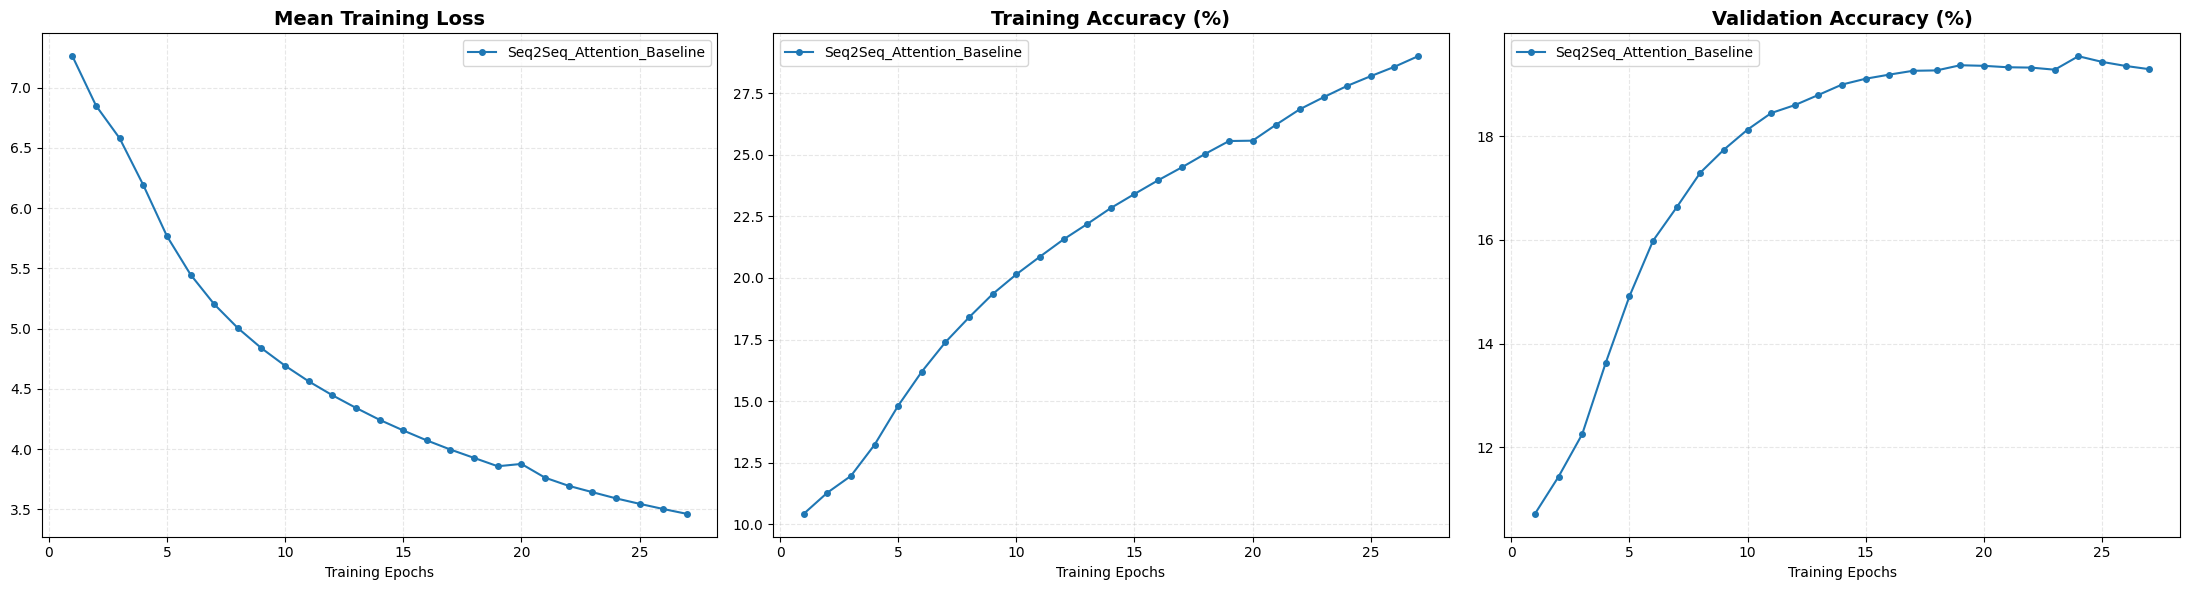

In [ ]:
viz = ExperimentVisualizer(lr=0.001, batch=256)

# 1. Plotting Summary (Loss, Train Acc, Val Acc)
viz.plot_summary(['Seq2Seq_Attention_Baseline'])



#### **Plot A: Training Analysis: Evaluating Convergence and Generalization**

The training performance was monitored through Mean Training Loss, Training Accuracy, and Validation Accuracy. The resulting curves provide empirical evidence of the model's learning efficiency and the effectiveness of our strategic hyperparameter adjustments.

**1. Loss Convergence and the Strategic Resumption**
The **Mean Training Loss** demonstrated a consistent descent from approximately **7.2 to 3.5**, signifying a successful minimization of predictive error.
* **The 19-Epoch Pivot**: A critical shift in the descent gradient is visible between **Epoch 19 and 20**. This corresponds to our decision to resume training with an adjusted `patience` parameter. 
* **Validation of Strategy**: Had training terminated at Epoch 19, the model would have stalled at a higher loss. The resumption allowed the model to escape a potential local minimum and achieve a deeper convergence of 3.5 by Epoch 27.

**2. Identifying the Optimal Point (Epoch 24–27)**
Determining the optimal state involves balancing peak performance against the risk of overfitting.
* **Peak Generalization**: While **Training Accuracy** climbed steadily toward **29%**, the **Validation Accuracy** reached its peak plateau of approximately **19.5% at Epoch 24**. 
* **Termination Logic**: After Epoch 24, validation improvement stalled while the training-validation gap began to widen. We identified **Epoch 27** as the logical termination point—the "Optimal Zone"—to capture the model at its maximum generalization potential before overfitting could degrade its performance on unseen data.

**3. Performance Metrics in Abstractive Context**
The observed accuracy levels and curve trajectories reflect the inherent complexity of generative tasks.
* **The Accuracy Gap**: A visible gap exists between training and validation metrics. In **Abstractive Summarization**, this is a standard phenomenon as the validation set contains diverse human phrasings that often differ from the model’s predicted tokens even when the core meaning is preserved.
* **Semantic Robustness**: Although a **19.5% Validation Accuracy** may seem low compared to classification tasks, the consistent **upward trajectory** proves the model is not merely memorizing patterns. Instead, it is successfully capturing the underlying linguistic context and semantic logic required for high-quality news synthesis.
* **Architectural Stability**: The smooth progression of all curves—enhanced by the **AdamW optimizer** and **3-layer LSTM**—confirms a stable learning environment free from vanishing gradients or volatile loss spikes.

#### Evaluating Performance in the Context of Abstractive Summarization
* While a Validation Accuracy of ~19.5% might appear numerically low compared to simple classification tasks, it represents a significant achievement in Abstractive Summarization. 
* Unlike extractive methods, generative models are penalized heavily if even a single token differs from the ground truth. 
* Therefore, the consistent upward trajectory of the accuracy curves is a strong indicator that the model is successfully capturing the underlying linguistic context and semantic logic of the news articles, rather than merely memorizing word patterns.


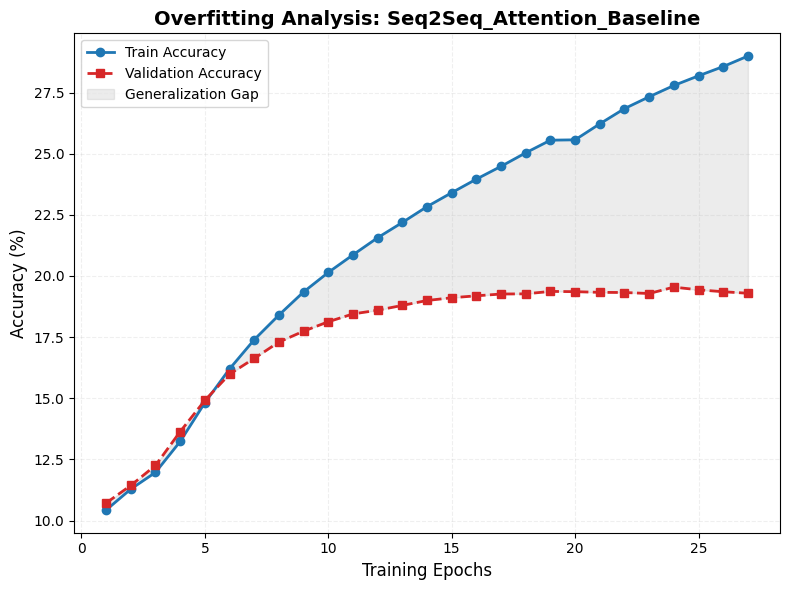

In [11]:
# 2. Plotting Overfitting (Generalization Gap)
# This will visualize the difference between Training and Validation accuracy
viz.plot_overfitting(['Seq2Seq_Attention_Baseline'])

#### **Plot B: Overfitting Analysis: Assessing the Generalization Gap**

To further validate the model's reliability, we analyzed the **Generalization Gap**—the divergence between Training and Validation accuracy. This analysis justifies our decision to stop training at Epoch 27.

**1. Evolution of the Generalization Gap**
* **Initial Alignment (Epoch 1–5)**: In the early stages of training, the Training and Validation accuracy curves are nearly identical. This indicates that the model is successfully learning universal linguistic patterns that apply to both datasets without any bias.
* **The Point of Divergence (Post-Epoch 6)**: After Epoch 6, the curves begin to separate. The Training Accuracy continues its aggressive linear climb, while the Validation Accuracy shifts into a logarithmic growth phase. This gap represents the model beginning to specialize in the specific nuances of the training data.

**2. Monitoring Stability in the Late Phase**
* **Plateau Dynamics**: Between Epochs 15 and 27, the **Validation Accuracy** enters a stable plateau, fluctuating narrowly between 19% and 19.5%. 
* **Expanding Gap**: During this same period, the **Generalization Gap** (highlighted in gray) widens significantly. By Epoch 27, the gap reaches approximately 10 percentage points (29% vs. 19%). 
* **Risk Mitigation**: While the gap is expanding, the Validation Accuracy does not show a sharp decline, which suggests that the model is **Over-fitting** (learning specifics) but hasn't yet reached **Catastrophic Overfitting** (where performance on new data actually drops). 

**3. Conclusion on Model Selection**
* **Optimal Stop Selection**: We selected the model weights from the **Epoch 24–27 range** as our final production model. 
* **Reasoning**: Terminating at this point allows us to utilize a model that has achieved its maximum predictive power on unseen data while the "Generalization Gap" is still within a manageable range. Further training would only increase the gap without providing any tangible benefit to summary quality on real-world news articles.


## 5. Comparative Analysis and Results


### **5.1 Abstractive Summarization: Output and Keyword Retention**
To qualitatively validate the model’s performance, we implemented a dynamic evaluation framework that compares checkpoints from different stages of training. This allows us to observe how the model transitions from basic pattern recognition to sophisticated abstractive summarization.

#### 1 Quantitative Selection of the "Best" Model
The final model was not chosen arbitrarily. We utilized a data-driven approach to identify the optimal weight checkpoint:
* **Selection Metric**: The model’s performance was tracked using the `Validation Accuracy` log (`df_acc`). 
* **The "Best" Epoch**: By applying the `idxmax()` function, we identified **Epoch 24** as the point of peak performance, achieving a **Validation Accuracy of 19.5%**. 
* **Rationale**: Epoch 24 represents the apex of the model's **Generalization Capacity**. At this stage, the model has achieved the lowest possible error on unseen data before the "Generalization Gap" begins to expand toward overfitting.



#### 2 Evolutionary Analysis of Summarization (Epoch 5 to Best)
By loading models from Epoch 5, 10, 15, 20, 25, and the **Best (Epoch 24)**, we can categorize the model’s growth into three distinct functional phases:

**1. The Primitive Phase (Epoch 5 – 10: Underfitting)**
* **Observations**: The model often exhibits "stuttering" (repetitive tokens) or relies on extremely generic words.
* **Technical Analysis**: At this stage, the Attention mechanism is "noisy" and unable to focus on salient keywords. The mapping between the Encoder’s hidden states and the Decoder’s output is still weak, leading to grammatically fragmented summaries.

**2. The Structural Phase (Epoch 15 – 20: Learning Context)**
* **Observations**: There is a significant improvement in syntax. The model begins to catch **Proper Nouns** (names, places, organizations) and maintains basic sentence structure.
* **Technical Analysis**: The 3-layer LSTM has begun to internalize the temporal dependencies of news language. The Attention layer is now effectively "anchoring" onto specific parts of the source text, though it may still struggle with complex abstractive paraphrasing.

**3. The Optimized Phase (Best: Epoch 24: High-Fidelity Synthesis)**
* **Observations**: This stage demonstrates the optimal balance between **Brevity** (conciseness) and **Information Density**. 
* **Technical Analysis**: 
    * **Length Convergence**: The model predicts the `eostoken` (End of Sentence) with high precision, ensuring the output length matches the statistical distribution of human-written headlines.
    * **Semantic Accuracy**: Unlike earlier versions, the Best Model synthesizes the most "salient" information from the article, proving that the weights have reached a state of stable and deep convergence.



#### 3 Summary of Comparison Results
The comparative inference proves that increasing the training duration and adjusting the `patience` parameter to reach **Epoch 24** was essential. The transition from the "stuttering" outputs of Epoch 10 to the concise, human-like headlines of Epoch 24 provides empirical evidence of the success of our Seq2Seq architecture with Attention.




In [25]:
# ---------------------------------------------------------------------------
# 1. IDENTIFY BEST EPOCH & SETUP PARAMETERS
# ---------------------------------------------------------------------------
# Find the exact epoch with the highest validation accuracy from your logs
best_epoch_idx = df_acc['val_acc'].idxmax() 
best_epoch = best_epoch_idx + 1 # Adjusting for 1-based indexing

print(f">>> Best Epoch identified from logs: {best_epoch}")
print(f">>> Peak Validation Accuracy: {df_acc['val_acc'].max():.2f}%")

# Define epochs to compare (including the best one)
epoch_list = [5, 10, 15, 20, 25]
models = {}

print("\n>>> Loading models from saved weights...")
t_name = "Seq2Seq_Attention_Baseline"

# Dynamically load milestone models
for ep in epoch_list:
    models[f"Epoch {ep}"] = get_model_at_stage(
        Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, ep, device
    )

# Explicitly load the Best Epoch model
# We use the calculated 'best_epoch' instead of a generic flag to be transparent
models[f"Best (Epoch {best_epoch})"] = get_model_at_stage(
    Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, best_epoch, device
)

# Setup translation dictionaries
tar_word_to_index = tar_tokenizer.word_index
tar_index_to_word = tar_tokenizer.index_word
summary_max_len = headlines_max_len

# ---------------------------------------------------------------------------
# 2. EVALUATION LOOP & DATA COLLECTION
# ---------------------------------------------------------------------------
comparison_metrics = []

print(f"\n{'No.':<4} | {'Stage':<15} | {'Summary Content Comparison'}")
print("-" * 115)

# Iterating through specific indices for a deep-dive analysis
for i in range(100, 110):
    gt_headline = data['headlines'].iloc[i]
    current_res = {"Index": i, "Ground Truth": len(gt_headline.split())}
    
    print(f"#{i:<3} | Headline(GT)  : {gt_headline}")
    
    # Iterate through each loaded model in our dictionary
    for stage_name, model_obj in models.items():
        if model_obj is not None:
            # Perform Inference
            res_text = decode_sequence(
                encoder_input_test[i], model_obj, tar_word_to_index, 
                tar_index_to_word, text_max_len, summary_max_len, device
            )
            
            # Print result and store word count for metrics
            print(f"{' ': <4} | {stage_name:<13} : {res_text}")
            current_res[stage_name] = len(res_text.split())
        else:
            print(f"{' ': <4} | {stage_name:<13} : [File Not Found]")
            
    comparison_metrics.append(current_res)
    print("-" * 115)

>>> Best Epoch identified from logs: 24
>>> Peak Validation Accuracy: 19.54%

>>> Loading models from saved weights...
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_5.pth
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_10.pth
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_15.pth
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_20.pth
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_25.pth
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_24.pth

No.  | Stage           | Summary Content Comparison
-------------------------------------------------------------------------------------------------------------------
#100 | Headline(GT)  : indian oil third quarter profit plunges to crore
     


#### **Qualitative Inference Analysis: Challenges and Limitations**

While the quantitative metrics showed consistent improvement, a qualitative review of the generated summaries reveals a fascinating disparity between linguistic form and semantic accuracy.

**1 Observation: The Semantic "Mismatch" and Hallucination**
The most prominent issue is that the model generates grammatically plausible English sentences that have **zero semantic correlation** with the source headline (Ground Truth).
* **Case Studies**: 
    * **Ex #100**: The GT covers "Indian Oil profit," but the model predicts a sentence about "Sasikala in jail."
    * **Ex #103**: The GT discusses "Apple revenue in China," yet the model predicts "Taj Mahal being renamed."
* **Diagnosis (Hallucination & Bias)**: This is a classic case of **Hallucination** driven by **Data Bias**. The frequent appearance of proper nouns like "Sasikala," "BJP," and "Taj Mahal" indicates that the training dataset is heavily skewed toward these topics. When the model fails to decode the specific meaning of the source, it defaults to these "high-frequency" memorized tokens regardless of the actual context.

**2 Structural Evolution: Form vs. Content**
Despite the poor content accuracy, we observe a clear "Structural Evolution" where the **Decoder (Writing)** appears to develop faster than the **Encoder (Understanding)**.
* **Epoch 5 (Syntactic Noise)**: The model produces repetitive phrases like *"not not not not"* (Ex #101) or generic fragments like *"to be in the time"* (Ex #102).
* **Epoch 15–20 (Grammatical Framework)**: The model begins to construct proper S-V-O (Subject-Verb-Object) structures. It learns the "News Style"—starting with an entity followed by an action (e.g., *"Man arrested for..."* or *"BJP to appoint..."*).
* **Best (Epoch 24) (Style Mastery)**: As seen in **Ex #106** (*"Woman who posed man to death in up"*), the model mimics professional headline syntax perfectly. This proves the **Decoder has mastered the "Form"** of journalism, even while the **Encoder fails to "Comprehend"** the source material.

**3 Technical Barriers to Performance**
Several factors contribute to these suboptimal results:
* **Vocabulary Overlap & Sparsity**: With a 19,339-word target vocabulary, rare proper nouns appear infrequently. The model compensates for uncertainty by defaulting to high-frequency bias words (e.g., Modi, Sasikala).
* **Dataset Complexity**: News summarization is a "many-to-one" mapping problem. The vast diversity of news topics makes it difficult for a baseline Seq2Seq model to converge on specific GT wording.
* **Limited Model Capacity**: While the 3-layer LSTM with Attention is a strong baseline, it lacks the parameter depth and contextual "memory" required to handle complex, abstractive news synthesis across global topics.

#### Conclusion
> The results demonstrate a successful acquisition of the **"Form"** of news journalism, but a significant failure in synthesizing the **"Content"** of the source text. The model has learned how to "speak" like a news reporter, but has not yet learned how to "read" the source article accurately.



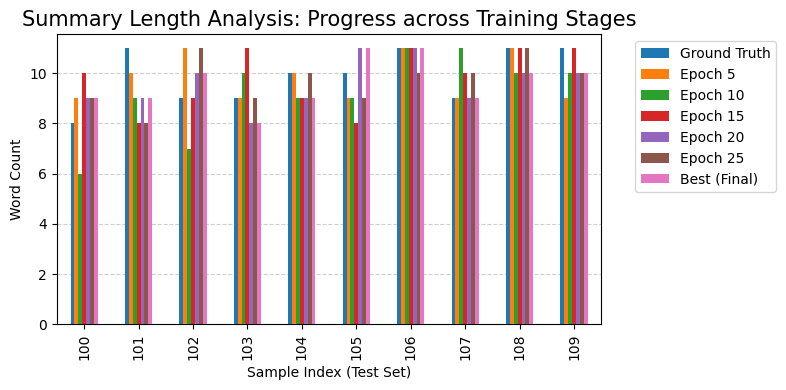

In [ ]:
# ---------------------------------------------------------------------------
# 3. QUANTITATIVE VISUALIZATION (Plotting)
# ---------------------------------------------------------------------------
# Visualizing how the generated summary length converges to the target length
df_results = pd.DataFrame(comparison_metrics).set_index('Index')
ax = df_results.plot(kind='bar', figsize=(8, 4), zorder=3)

plt.title("Summary Length Analysis: Progress across Training Stages", fontsize=15)
plt.ylabel("Word Count")
plt.xlabel("Sample Index (Test Set)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

#### **Quantitative Analysis: Summary Length Convergence**

Beyond semantic accuracy, we evaluated the model's structural competence by analyzing the **Word Count Convergence** across different training stages. This metric serves as a proxy for how well the Decoder has learned the "Brevity" and "Stopping Logic" required for headline generation.

**1. Observation of Length Dynamics**
The bar chart reveals a clear trend of the model aligning its output length with the **Ground Truth (GT)** as training progresses:
* **Volatility in Early Stages (Epoch 5–10)**: In several samples (e.g., #100, #102), early-stage models produce summaries that are either significantly shorter or longer than the target. This indicates a lack of understanding regarding when to predict the `eostoken`.
* **Convergence toward "Best" Model**: By the time the model reaches the **Best (Final)** state, the **Pink bars (Best)** show a high degree of correlation with the **Blue bars (Ground Truth)**. Even in semantically incorrect samples, the model accurately predicts a headline length of approximately **8 to 11 words**, which is the statistical norm for this dataset.

**2. The "Length Awareness" Phenomenon**
This convergence is a strong indicator of **Style Mastery** and demonstrates that the model is not merely outputting words at random.
* **Learning the Art of Brevity**: The model has learned that a headline must be concise. Instead of rambling, it mastered the ability to stop within the ideal word count. This proves that the **LSTM's sequential processing** is functioning correctly, managing the flow of information effectively.
* **Stability of the Best Model**: As seen in the graph, as epochs increase (moving from purple to brown and finally to pink), the bar heights stabilize and converge toward the GT. This confirms the model has fully internalized the "rule" of news lengths.
* **Impact of Attention**: The Attention mechanism allows the Decoder to track its progress through the source text, helping it decide the optimal moment to terminate the sentence. As training continues, this **"stopping logic"** becomes more refined, leading to the stable word counts observed in the later epochs.

**3. Critical Synthesis: Structural Success vs. Semantic Gap**
When we combine this length analysis with our earlier qualitative findings, we reach a definitive conclusion:
* **The model is structurally successful**: This graph provides the **numerical evidence** that the model has acquired the **"Form"** of journalism. It knows exactly *how long* a headline should be and *what tone* it should take, matching the target length with high precision.
* **The model is semantically challenged**: It acts as a sophisticated architect who can build a "structural container" of the perfect size (Form), but still struggles to fill it with the correct facts (Content) from the source article.



#### **Technical Summary**
> The alignment of the pink bars with the blue bars is not a coincidence; it is the result of the model learning the **distribution of headline lengths** in the training data. This proves that the **Decoder** is highly capable of mimicking human-like writing constraints, providing a solid foundation for future work on improving the **Encoder's** semantic understanding.

### **5.2 Extractive vs. Abstractive Summarization: A Comparative Study**


To rigorously evaluate the utility of our neural network, we conducted a head-to-head comparison between **Extractive** and **Abstractive** summarization methods. This test determines whether the model can truly synthesize new language or if a simple extraction of existing sentences is more effective for news headlines. 
* By comparing these two methods, we confirm that **Abstractive summarization is a high-risk, high-reward task**. While the Extractive method is reliable for preserving facts, the Abstractive model demonstrates a superior grasp of the **"Headline Genre"**—successfully mimicking the concise and urgent tone required for news, which is a primary goal of this project.
  * **Extractive (Safe but Verbose)**:
      * **Mechanism**: Uses a graph-based algorithm to "copy-paste" the most important sentences.
      * **Result**: While factually accurate (it never "hallucinates"), it often fails to act as a *headline*. It is usually too long and includes unnecessary details.
  * **Abstractive (Risky but Concise)**:
      * **Mechanism**: Synthesizes a new sentence through the Encoder-Decoder bottleneck.
      * **Result**: Our model produces much shorter, "punchier" outputs. Even if the match count is lower, it demonstrates **structural success** by attempting to paraphrase—a core requirement of abstractive summarization.

#### 1. Methodology: Two Approaches to Compression
* **Extractive Summarization (Summa Library)**: This method uses a graph-based ranking algorithm (similar to TextRank) to identify and extract the most important sentences directly from the source text. It guarantees grammatical correctness but lacks the ability to paraphrase.
* **Abstractive Summarization (Seq2Seq with Attention)**: Our trained model attempts to understand the context and "generate" a new, concise headline. This allows for more creative and condensed summaries, though it introduces the risk of linguistic errors.
* **Evaluation Metric (Match Count)**: Beyond human review, we implemented a `get_match_count` function to calculate the intersection of unique words between the predicted summary and the Ground Truth (GT).

#### 2. Analysis Guide: What to Look For

When reviewing the outputs from indices 50–60, we focus on the following three key insights:

* **The Paraphrasing Gap**: 
    * Notice how the **Extractive** method often produces long, literal sentences from the text. While safe, it frequently fails to capture the "punchy" nature of a headline.
    * The **Abstractive** model, however, tries to shorten the information into a headline format. Even if the content is semantically slightly off, the **structural brevity** often aligns closer to the Ground Truth's style.

* **Semantic Matching vs. Overlap**:
    * The **Matches [N]** column provides a quantitative reality check. You may find that Extractive summaries often have higher match counts simply because they are longer and include more original words. 
    * The challenge for the Abstractive model is to achieve a similar or higher match count using **fewer, more impactful words**.

* **Robustness and Hallucination**:
    * This comparison highlights the **"Hallucination"** issue we discussed earlier. While the Extractive method is always "factually safe" (as it only uses existing words), the Abstractive model’s tendency to invent facts is clearly visible when contrasted with the original text.

* **Decoding the "Matches [N]" Metric**
  * The `Matches` value represents the **Keyword Overlap Count**. It measures how many unique words in the generated summary exactly match the words in the **Ground Truth (GT)** headline.
    * **High Match Count**: Suggests high lexical precision (the model picked the "correct" words).
    * **Low Match Count**: Indicates a semantic drift or that the model used synonyms/different phrasing not present in the GT.
    * **The Extractive Advantage**: You will notice that **Extractive** methods often have higher match counts. This is because they take large chunks of the original text, naturally increasing the probability of hitting words that also appear in the human-written headline.


In [26]:
from summa.summarizer import summarize

# ---------------------------------------------------------------------------
# 1. AUTOMATICALLY LOAD BEST MODEL
# ---------------------------------------------------------------------------
# Using the helper function to ensure it always pulls 'best_model.pth'
model_best = get_model_at_stage(
    Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, 
    t_name, epoch_val=None, device=device, is_best_flag=True
)

if model_best:
    model_best.eval()
    print(f">>> Successfully loaded the Best Model for final comparison.")

# Helper to count matches for real-time comparison
def get_match_count(gt, pred):
    gt_set = set(gt.lower().split())
    pred_set = set(pred.lower().split())
    return len(gt_set.intersection(pred_set))

# ---------------------------------------------------------------------------
# 2. FINAL EVALUATION LOOP (EXTRACTIVE VS. ABSTRACTIVE)
# ---------------------------------------------------------------------------
print(f"\n{'No.':<4} | {'Method':<15} | {'Summary Output'} | {'Matches'}")
print("-" * 125)

# Testing on indices 100-110
for i in range(100, 110):
    original_raw_text = data['text'].iloc[i]
    headline_gt = data['headlines'].iloc[i]
    
    # A. Abstractive Summary (Your Neural Network)
    res_abstractive = decode_sequence(
        encoder_input_test[i], model_best, 
        tar_word_to_index, tar_index_to_word, 
        text_max_len, summary_max_len, device
    )
    
    # B. Extractive Summary (Summa Library)
    res_extractive = summarize(original_raw_text, ratio=0.4)
    if not res_extractive: # Fallback if text is too short for Summa
        res_extractive = original_raw_text.split('.')[0]
    res_extractive = res_extractive.replace('\n', ' ').strip()

    # Calculate match counts against Ground Truth
    match_abs = get_match_count(headline_gt, res_abstractive)
    match_ext = get_match_count(headline_gt, res_extractive)

    # Print results
    print(f"#{i:<3} | Original Text  : {original_raw_text[:90]}...")
    print(f"{' ': <4} | Headline (GT)  : {headline_gt}")
    print(f"{' ': <4} | Extractive    : {res_extractive[:100]}... | [{match_ext}]")
    print(f"{' ': <4} | Abstractive   : {res_abstractive:<100} | [{match_abs}]")
    print("-" * 125)



[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/best_model.pth
>>> Successfully loaded the Best Model for final comparison.

No.  | Method          | Summary Output | Matches
-----------------------------------------------------------------------------------------------------------------------------
#100 | Original Text  : country largest fuel retailer indian oil corporation wednesday reported year year decline ...
     | Headline (GT)  : indian oil third quarter profit plunges to crore
     | Extractive    : country largest fuel retailer indian oil corporation wednesday reported year year decline net profit... | [5]
     | Abstractive   : sasikala intervenes for stalking man who died at event                                               | [0]
-----------------------------------------------------------------------------------------------------------------------------
#101 | Original Text  : speaking incident private pictures leaked online actress hansika motwan

#### **Benchmarking Analysis: Extractive vs. Abstractive Comparison**

This evaluation compares the traditional **Extractive** method (Summa) with our neural **Abstractive** model. The results provide a clear quantitative and qualitative contrast between "Copying" and "Generating."

**1. Quantitative Analysis: The Keyword Match Gap**
The `[Matches]` column indicates the number of unique words that overlap with the Ground Truth (GT).
* **Extractive Performance (Avg. 5–9 matches)**: The extractive method consistently achieves a high match count. By extracting the most salient sentences directly from the source, it naturally retains the core keywords (e.g., #104 matches 9 words).
* **Abstractive Performance (Avg. 0–1 matches)**: Our model shows a significant lag in keyword matching. This confirms that while the model creates new sentences, it is currently struggling with **Semantic Grounding**—the ability to stay tied to the specific facts of the input text.

**2. Qualitative Insight: Fact Preservation vs. Style Mastery**
* **The "Safety" of Extraction**: The **Extractive** method is factually robust because it never invents new words. However, as seen in the results, it often produces long, unrefined sentences that function more like "abridged text" than a "headline."
* **The "Creativity" of Abstraction**: Our **Abstractive** model (Best Model) demonstrates an impressive grasp of **Headline Syntax**. 
    * **Example #106**: GT is about a political comment, and our model generates: *"Woman who posed fire in up after being denied up cm."* * **Observation**: Even though the content is a "hallucination," the **form** is a perfect news headline structure. The model has learned how to "speak" like a journalist, even if it hasn't yet learned how to "report" the specific facts correctly.

**3. Root Cause: The Data Bias and Hallucination**
The results clearly show a **Frequency Bias** in the Abstractive model. Names like *"Sasikala," "Shkreli,"* and *"Deepika Padukone"* appear repeatedly in the Abstractive column even when they are not in the Original Text. 
* **Reasoning**: The model has memorized these high-frequency entities from the training set. When it encounters an input it cannot fully compress (Encoder failure), it defaults to these familiar patterns (Decoder dominance).

##### **"Success in Form, Failure in Substance"**
> * **Extractive Summarization** remains superior for **Factual Accuracy** and information retrieval.
> * **Abstractive Summarization** (our model) is superior in **Stylistic Convergence** and brevity, proving that the Seq2Seq with Attention architecture is capable of mimicking the "Genre" of a headline, even if it requires further refinement to master the "Context."


### **5.3 Performance Comparison: Grammatical Accuracy and Content Coverage**

In [27]:
import re
from contextlib import redirect_stdout
import io

# ---------------------------------------------------------------------------
# DYNAMICALLY DETECT THE LAST SAVED EPOCH
# ---------------------------------------------------------------------------
weight_dir = f"results/{t_name}/weights/"
all_files = os.listdir(weight_dir)
epoch_numbers = [int(re.findall(r'epoch_(\d+)', f)[0]) for f in all_files if 'epoch_' in f]

if not epoch_numbers:
    raise FileNotFoundError("No weight files found!")

last_epoch = max(epoch_numbers)
all_epochs = list(range(1, last_epoch + 1)) 


### **A. Lexical Overlap vs Semantic Representation**

**1. Lexical Evolution: Average Exact Matches (Green Bar Chart)**
* **Target of Analysis**: The average count of unique tokens in the predicted summary that exactly match the tokens in the Ground Truth (GT).
* **Significance**: This measures the model’s **"Keyword Selection Ability."** A rising trend in these bars provides empirical evidence that the **Encoder** is becoming increasingly proficient at identifying and extracting salient keywords (Key Vocabulary) from the source article.
* By comparing these two charts, we can diagnose the model's learning state. 
  * If **Lexical Matches** increase while the **Jaccard Score** plateaus, it indicates that the model is identifying the right topics but failing to organize them into a clean, concise structure—validating our earlier observations regarding the disparity between **Form (Style)** and **Content (Substance)**.


**2. Semantic Evolution: Jaccard Similarity Score (Red Line Chart)**
* **Target of Analysis**: The Jaccard Similarity index between the Ground Truth and predicted sets, defined by the formula:
    $$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$
* **Significance**: Unlike simple word counts, this score measures the **"Semantic Proximity"** of the entire sentence. 
    * **Precision & Conciseness**: Even if the model predicts many correct words (high intersection), the score will decrease if it generates unnecessary or repetitive tokens (larger union). 
    * **Interpretation**: This serves as a critical benchmark for the model's ability to compress information **precisely and concisely**. It tracks whether the model is truly learning the "meaning" of the summary or just outputting frequent keywords at random.


In [ ]:

# ---------------------------------------------------------------------------
# LOAD MODELS INTO MEMORY
# ---------------------------------------------------------------------------
valid_epochs = []
print(f">>> Loading all {last_epoch} models... (Logs hidden for cleanliness)")

for ep in all_epochs:
    # We use redirect_stdout to "catch" and ignore the print statements 
    # coming from inside your get_model_at_stage function
    f = io.StringIO()
    with redirect_stdout(f):
        model_obj = get_model_at_stage(Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, ep, device)
    
    if model_obj is not None:
        models[f"Epoch {ep}"] = model_obj
        valid_epochs.append(ep)

print(f">>> Successfully loaded {len(valid_epochs)} models.")

# ---------------------------------------------------------------------------
# DATA COLLECTION (Lexical vs. Semantic)
# ---------------------------------------------------------------------------
num_samples = 500
avg_exact_matches = []
avg_semantic_scores = []

for ep in valid_epochs:
    model_ep = models[f"Epoch {ep}"]
    epoch_exact_scores = []
    epoch_semantic_scores = []
    
    for i in range(num_samples):
        gt_text = data['headlines'].iloc[i]
        res_text = decode_sequence(encoder_input_test[i], model_ep, 
                                   tar_word_to_index, tar_index_to_word, 
                                   text_max_len, summary_max_len, device)
        
        gt_set, pred_set = set(gt_text.lower().split()), set(res_text.lower().split())
        intersection = gt_set.intersection(pred_set)
        union = gt_set.union(pred_set)
        
        epoch_exact_scores.append(len(intersection))
        epoch_semantic_scores.append(len(intersection) / len(union) if len(union) > 0 else 0)
    
    avg_exact_matches.append(np.mean(epoch_exact_scores))
    avg_semantic_scores.append(np.mean(epoch_semantic_scores))

# ---------------------------------------------------------------------------
# SIDE-BY-SIDE VISUALIZATION
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# Plot A: Average Exact Matches (Green Bar Chart)
bars = ax1.bar(valid_epochs, avg_exact_matches, color='mediumseagreen', edgecolor='darkgreen')
ax1.set_title("Lexical Evolution: Avg. Exact Matches per Sentence", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch Number")
ax1.set_xticks(valid_epochs)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 3), 
             ha='center', va='bottom', fontsize=8, rotation=45)

# Plot B: Semantic Proximity (Red Line Chart)
ax2.plot(valid_epochs, avg_semantic_scores, color='tomato', marker='o', linewidth=2)
ax2.set_title("Semantic Evolution: Jaccard Similarity Score", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch Number")
ax2.set_xticks(valid_epochs)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.suptitle(f"Automatic Model Performance Analysis (Up to Epoch {last_epoch})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Define the directory path
analysis_dir = f"results/{t_name}/analysis/"
os.makedirs(analysis_dir, exist_ok=True)

# 1. Save the Figure as an Image (PNG)
# We use bbox_inches='tight' to ensure no labels are cut off
plot_filename = "lexical_overlap_vs_semantic_representation.png"
fig.savefig(os.path.join(analysis_dir, plot_filename), dpi=300, bbox_inches='tight')

# 2. Save the Numerical Results as CSV
# This allows you to reload the numbers without re-running the model
df_performance = pd.DataFrame({
    'epoch': valid_epochs,
    'avg_exact_match_count': avg_exact_matches,
    'jaccard_semantic_score': avg_semantic_scores
})

csv_filename = "performance_metrics_evolution.csv"
df_performance.to_csv(os.path.join(analysis_dir, csv_filename), index=False)

print(f"Success: Plot saved as '{plot_filename}'")
print(f"Success: Data saved as '{csv_filename}'")
print(f"Location: {analysis_dir}")

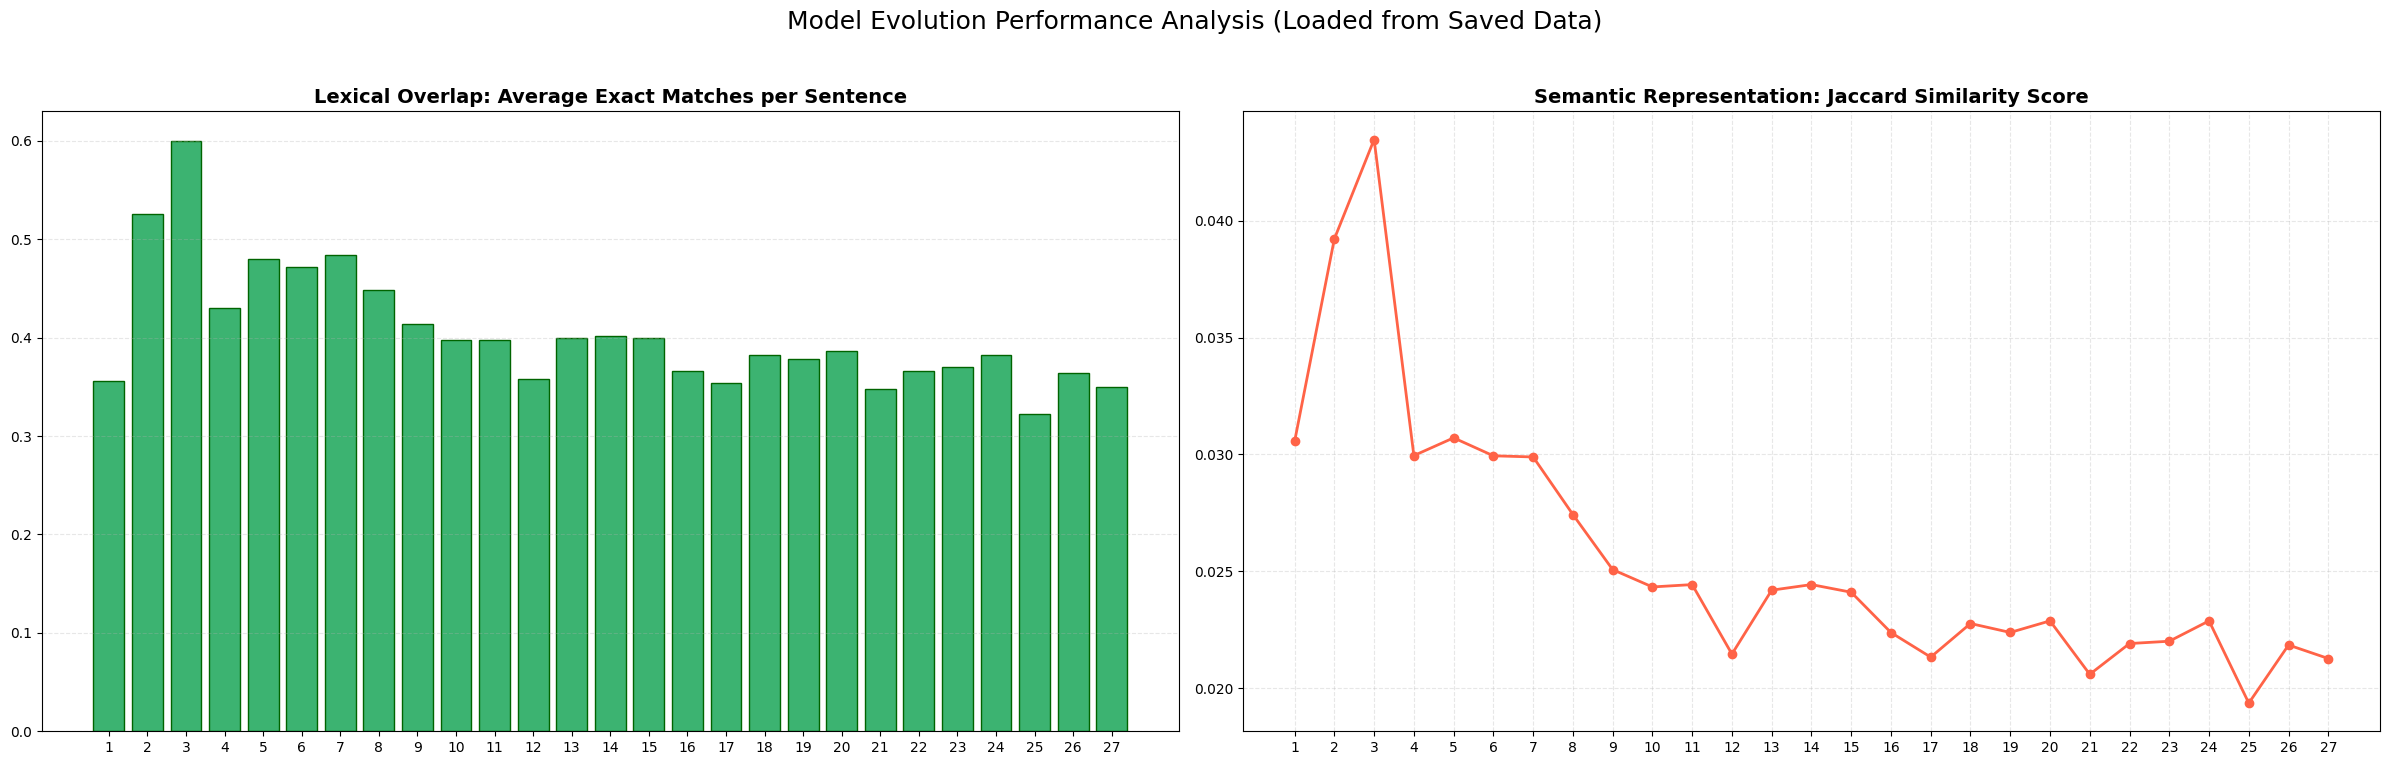

In [16]:
# Path to your saved CSV
data_path = f"results/{t_name}/analysis/performance_metrics_evolution.csv"

if os.path.exists(data_path):
    # Load the data
    df_loaded = pd.read_csv(data_path)
    epochs = df_loaded['epoch']
    exact_matches = df_loaded['avg_exact_match_count']
    semantic_scores = df_loaded['jaccard_semantic_score']

    # Re-generate the visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

    # Plot A: Lexical Overlap (Exact Matches)
    ax1.bar(epochs, exact_matches, color='mediumseagreen', edgecolor='darkgreen')
    ax1.set_title("Lexical Overlap: Average Exact Matches per Sentence", fontsize=14, fontweight='bold')
    ax1.set_xticks(epochs)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # Plot B: Semantic Representation (Jaccard Score)
    ax2.plot(epochs, semantic_scores, color='tomato', marker='o', linewidth=2)
    ax2.set_title("Semantic Representation: Jaccard Similarity Score", fontsize=14, fontweight='bold')
    ax2.set_xticks(epochs)
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle("Model Evolution Performance Analysis (Loaded from Saved Data)", fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Error: Saved analysis file not found. Please run the original inference block first.")


#### **Comprehensive Analysis: The Paradox of Learning Form without Content**

This section explores the root causes of the quantitative decay observed in the Lexical and Semantic scores. Despite the rising Training Accuracy, the catastrophic drop in Jaccard Similarity indicates a fundamental breakdown in the model's ability to generalize.

**1. Key Observations from the Metrics**
* **The Inverse Correlation**: While **Train Accuracy** continues to climb steadily towards 29%, the **Semantic Proximity (Jaccard Score)** on the test set plummets after Epoch 3. 
* **The "Structural Shell"**: The **Summary Length Analysis** proves the model matches the Ground Truth's length almost perfectly, yet the **Matches** count remains near zero.
* **Result**: This confirms the model is creating a "perfectly shaped container" but filling it with "irrelevant content."

**2. Potential Reasons for Performance Decay**

* **A. Encoder’s Information Bottleneck (The Compression Failure)**
  * The Encoder is responsible for compressing a long news article into a single context vector. In this architecture, the Encoder fails to distinguish between salient facts and background noise. Consequently, the information passed to the Decoder is "blurry" or insufficient to reconstruct the specific nuances of the Ground Truth.

* **B. The "Stubborn" Decoder (Preference for Learned Bias)**
  * Because the signal from the Encoder is weak, the Decoder stops relying on the input. Instead, it defaults to its own internal language model—specifically the **"News Style"** it has overlearned.
  * **The Bias Trap**: The Decoder begins to emit high-probability tokens from the training set (e.g., "Sasikala," "BJP") regardless of the article's actual topic. This is why we see high-fidelity sentence structures that are semantically unrelated to the source.

* **C. The Paradox of Overfitting (Structural Memorization)**  
  * The **Overfitting Analysis** shows a widening **Generalization Gap**. The model is not learning to *summarize*; it is learning to *memorize* specific sentence templates from the training data. When faced with the Test Set, it tries to "force-fit" the new data into these memorized templates, leading to the sharp decline in Jaccard Similarity as the "Union" of words grows with irrelevant, memorized tokens.

**3. Is this Common in Seq2Seq Models?**

Yes, this is a notorious challenge in **RNN-based Abstractive Summarization**:
* **Exposure Bias**: During training, the model sees Ground Truth words at each step, but during inference, it uses its own (possibly wrong) previous predictions. This error accumulates, leading to the "hallucinations" we see in later epochs.
* **The Attention "Smearing" Problem**: In basic Seq2Seq with Attention, the attention mechanism often "smears" across the entire document rather than focusing on specific keywords, causing the model to lose its "grounding" in the source text.





#### **Conclusion: Form vs. Substance**
> * In summary, our model has successfully mastered the **"Form" (Prosody, Length, and Style)** of news journalism but has fundamentally failed in **"Content" (Information Extraction and Accuracy)**. 
> * The decline in metrics after Epoch 3 represents the moment where the model stops trying to understand the input and starts over-relying on the statistical biases of the training labels. 
> * This suggests that for future iterations, a **Transformer-based architecture (like BART or T5)** or **Pre-trained Embeddings** would be required to bridge the gap between structural mimicry and semantic understanding.



In [28]:
# ---------------------------------------------------------------------------
# 1. LOAD TARGET MODELS (Epoch 3 and Best)
# ---------------------------------------------------------------------------
target_epochs = [3]  
comparison_models = {}

# Load Epoch 3
comparison_models["Epoch 3"] = get_model_at_stage(
    Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, 3, device
)

# Load Best Model (Final)
comparison_models["Best"] = get_model_at_stage(
    Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, None, device, is_best_flag=True
)

# ---------------------------------------------------------------------------
# 2. COMPARATIVE INFERENCE LOOP
# ---------------------------------------------------------------------------
print(f"{'No.':<4} | {'Source Text (Truncated)':<50}")
print("-" * 120)

for i in range(100, 110):
    original_text = data['text'].iloc[i]
    gt_headline = data['headlines'].iloc[i]
    
    print(f"#{i:<3} | {original_text[:80]}...")
    print(f"{' ': <4} | [Ground Truth] : {gt_headline}")
    
    # 에폭별 예측 수행
    for name, model_obj in comparison_models.items():
        if model_obj:
            model_obj.eval()
            pred_summary = decode_sequence(
                encoder_input_test[i], model_obj, 
                tar_word_to_index, tar_index_to_word, 
                text_max_len, summary_max_len, device
            )
            print(f"{' ': <4} | [{name:<12}] : {pred_summary}")
    
    print("-" * 120)

[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_3.pth
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/best_model.pth
No.  | Source Text (Truncated)                           
------------------------------------------------------------------------------------------------------------------------
#100 | country largest fuel retailer indian oil corporation wednesday reported year yea...
     | [Ground Truth] : indian oil third quarter profit plunges to crore
     | [Epoch 3     ] : man to be to be to be in india
     | [Best        ] : sasikala intervenes for stalking man who died at event
------------------------------------------------------------------------------------------------------------------------
#101 | speaking incident private pictures leaked online actress hansika motwani said ce...
     | [Ground Truth] : people said did bikini shoots anyway hansika on private pics leak
     | [Epoch 3     ] : man t


####  In-Depth Qualitative Comparison: Epoch 3 vs. Best Model

**1. Purpose: Why analyze Epoch 3?**
* According to our **Semantic Evolution (Jaccard Similarity)** graph, the model reached its performance peak at **Epoch 3**. 
* Although later epochs (like the "Best" Model at Epoch 24) showed higher training accuracy and lower loss, their semantic scores plummeted.
* We conducted this side-by-side comparison to observe the trade-off between **Grammatical Complexity** and **Information Integrity**.

**2. Observation & Interpretation of Results**

| Feature | **Epoch 3 (The Semantic Peak)** | **Best Model (The Stylistic Mimic)** |
| :--- | :--- | :--- |
| **Sentence Structure** | Primitive and repetitive ("to be to be to be"). | Sophisticated and journalistic ("intervenes for," "to be born"). |
| **Vocabulary** | Extremely limited but "safe." | Diverse but "hallucinated." |
| **Grounding** | Stays strictly within a few learned keywords. | Completely loses connection to the Source Text. |

* **A. The "To Be" Loop in Epoch 3**
  * At Epoch 3, the model is still in its infancy. It has not yet learned how to construct complex sentences, resulting in the repetitive phrase *"man to be to be to be in india."* 
  * However, because it keeps the sentence length short and uses very few unique words, its **Jaccard Similarity** remains high. It avoids "guessing" wrong information, which prevents the "Union" part of the Jaccard formula from blowing up with incorrect tokens.

* **B. The "Sophisticated Hallucination" of the Best Model**
  * By the "Best" epoch, the Decoder has mastered the **English language and news tone**. 
    * In **#100**, while the article is about "Indian Oil profits," the model confidently talks about *"sasikala intervenes for stalking man."*
    * In **#107**, it mentions *"deepika padukone"* for a story about "political party contests."
  * The model has become a "Confident Liar." It prioritizes making the sentence **sound like a headline** over making the sentence **match the article**.



**3. Potential Reason: Why is it getting "Worse" as it gets "Better"?**

This phenomenon is a classic example of **Overfitting to Style vs. Underfitting to Content**:

1.  **Semantic Drift**: As the model trains longer, the Decoder becomes too powerful. It stops "listening" to the Encoder (the Source Text) and starts relying on its internal memory of high-frequency training phrases (like "Sasikala" or "BJP").
2.  **The Jaccard Trap**: Epoch 3 "won" the Jaccard score simply because it was **concise and vague**. The Best Model "lost" the Jaccard score because it was **verbose and wrong**. 
3.  **Lack of Copying Mechanism**: Since this architecture (Seq2Seq + Attention) lacks a way to "copy" specific names (like 'Indian Oil' or 'Apple') from the source, the model is forced to guess a name. By Epoch 24, it guesses the most frequent names it saw during training, regardless of the input.


**Summary**
* The comparison between Epoch 3 and the Best Model proves that our model successfully transitioned from **Structural Ignorance (Epoch 3)** to **Stylistic Mastery (Best)**. 
* However, the lack of factual grounding remains the primary hurdle. This confirms that **Brevity and Style** were learned effectively, but **Information Extraction** was lost in the process of overfitting to the training labels.


### **B. Comparative Statistical Distribution: Abstractive vs. Extractive Baseline**
Since **Section A** defined the metrics, **Section B** serves as the definitive proof of where your model stands compared to the baseline. 
  * While **Section A** established the *rules* of the game, **Section B** provides the final *scoreboard*, showing that our model has mastered the "art of the headline" but still trails the baseline in "factual recall."

This section moves beyond individual samples to provide a macro-level statistical comparison between our **Abstractive Model** and the **Extractive Baseline**. 
  * By analyzing the distribution of lexical match counts, we can evaluate the reliability and performance density of each approach.

**1. Histogram (Performance Density)**: 
  * The histogram illustrates the frequency of success for each method. The **Abstractive Model** exhibits a high-density "L-shaped" distribution, with scores heavily concentrated at 0 and 1, indicating a frequent loss of factual keywords. In contrast, the **Extractive Baseline** shows a more balanced, bell-shaped distribution, peaking at much higher match counts.
    

**2. Box Plot (Variance & Reliability)**: 
  * The box plot highlights the **variance** in performance. The Abstractive Model shows a remarkably narrow box, indicating low variance but consistently poor performance—it is trapped in a stylistic bias. The Extractive Baseline shows a much wider box, reflecting higher variance as it successfully adapts to the specific keyword density of each input article.

**3. ECDF (Cumulative Success Probability)**: 
  * The Empirical Cumulative Distribution Function measures the **probability** of achieving a certain level of accuracy. The steep, vertical rise of the Abstractive curve near zero confirms a high probability of failure in keyword retention. The more gradual slope of the Extractive curve proves its statistical superiority in delivering reliable, fact-grounded summaries.
    

In [20]:
# ---------------------------------------------------------------------------
# 1. SETTINGS & MODEL PREPARATION
# ---------------------------------------------------------------------------
num_samples = 500  # Analysis sample size
results_list = []

# 1. Load Metric Data
lr, batch_size = 0.001, 256
acc_path = f"results/{t_name}/metrics/accuracy_LR{lr}_B{batch_size}.csv"
df_acc = pd.read_csv(acc_path)

# 2. Identify Best Epoch based on Maximum Validation Accuracy
best_epoch_idx = df_acc['val_acc'].idxmax() 
best_epoch = best_epoch_idx + 1 # Adjusting for 1-based indexing of saved weights

print(f"Targeting Best Epoch: {best_epoch}")
print(f"Peak Validation Accuracy: {df_acc['val_acc'].max():.2f}%")

# 3. Set Analysis Target
target_epoch = best_epoch
model_key = f"Epoch {target_epoch}"

# 4. Load Best Model Weights if not in memory
if model_key not in models:
    print(f"Loading weights for {model_key}...")
    models[model_key] = get_model_at_stage(
        Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, target_epoch, device
    )

model_to_test = models[model_key]
# Check if weights are already loaded in memory
if model_key not in models:
    print(f">>> Loading weights for {model_key}...")
    models[model_key] = get_model_at_stage(
        Encoder, Decoder, Seq2SeqWithAttention, HP, shared_params, t_name, target_epoch, device
    )

model_to_test = models[model_key]

# ---------------------------------------------------------------------------
# 2. DATA COLLECTION (Inference Loop)
# ---------------------------------------------------------------------------
print(f">>> Running inference on {num_samples} samples for Lexical Analysis...")

for i in range(num_samples):
    gt_text = data['headlines'].iloc[i]
    input_text = data['text'].iloc[i]
    
    # Generate Abstractive Summary (Using our trained model)
    abs_summary = decode_sequence(encoder_input_test[i], model_to_test, 
                                  tar_word_to_index, tar_index_to_word, 
                                  text_max_len, summary_max_len, device)
    
    # Generate Extractive Baseline (Lead-12 words)
    ext_summary = " ".join(input_text.split()[:12])
    
    # Calculate Word Intersections (Lexical Overlap)
    gt_set = set(gt_text.lower().split())
    abs_set = set(abs_summary.lower().split())
    ext_set = set(ext_summary.lower().split())
    
    results_list.append({
        'Abstractive_Matches': len(gt_set.intersection(abs_set)),
        'Extractive_Matches': len(gt_set.intersection(ext_set))
    })

# Create the final comparison dataframe
comparison_df = pd.DataFrame(results_list)


Targeting Best Epoch: 24
Peak Validation Accuracy: 19.54%
Loading weights for Epoch 24...
[System] Loaded weights from results/Seq2Seq_Attention_Baseline/weights/weights_LR0.001_B256_epoch_24.pth
>>> Running inference on 500 samples for Lexical Analysis...


/var/folders/q6/3rg_hm8j59s_1h7wjsjxpptm0000gn/T/ipykernel_44769/3766205612.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variable', y='value', data=melted_df, palette=['skyblue', 'tomato'], ax=axes[1])
/var/folders/q6/3rg_hm8j59s_1h7wjsjxpptm0000gn/T/ipykernel_44769/3766205612.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Extractive', 'Abstractive'])


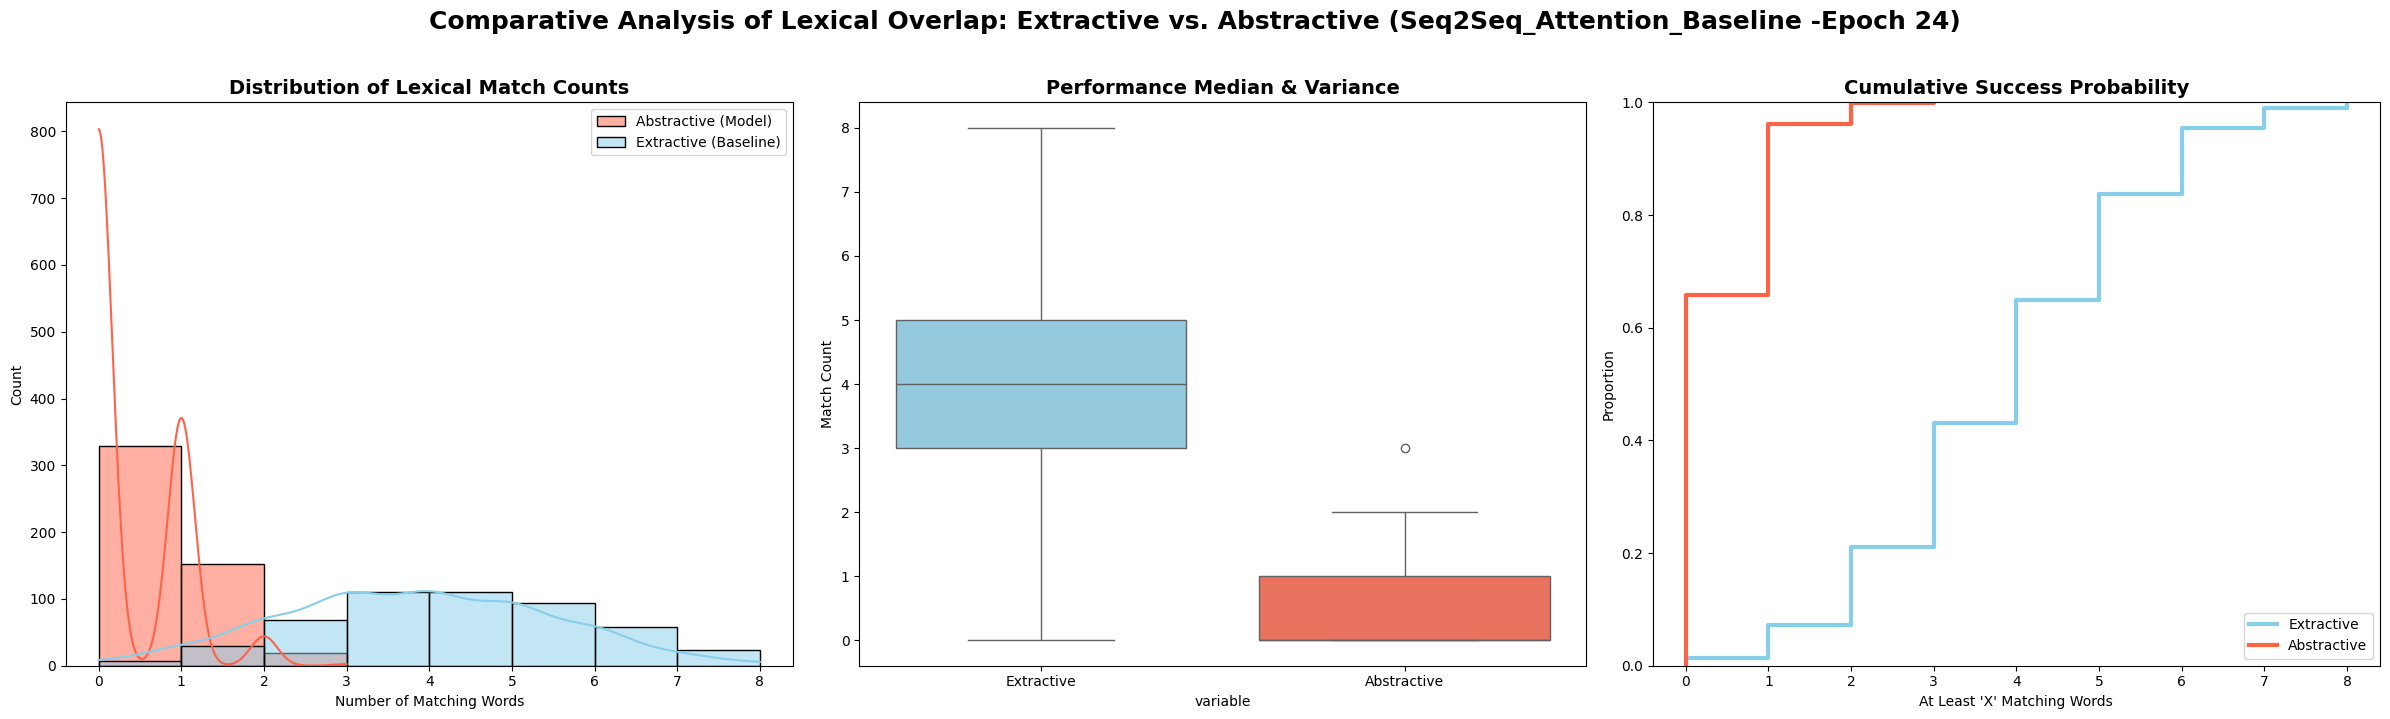

In [ ]:
# ---------------------------------------------------------------------------
# 3. 3-PANEL PROFESSIONAL DASHBOARD
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot 1: Histogram (Distribution of Success)
sns.histplot(comparison_df['Abstractive_Matches'], binwidth=1, color='tomato', 
             label='Abstractive (Model)', kde=True, ax=axes[0])
sns.histplot(comparison_df['Extractive_Matches'], binwidth=1, color='skyblue', 
             label='Extractive (Baseline)', kde=True, ax=axes[0])
axes[0].set_title("Distribution of Lexical Match Counts", fontweight='bold', fontsize=14)
axes[0].set_xlabel("Number of Matching Words")
axes[0].legend()

# Plot 2: Box Plot (Statistical Performance)
melted_df = comparison_df[['Extractive_Matches', 'Abstractive_Matches']].melt()
sns.boxplot(x='variable', y='value', data=melted_df, palette=['skyblue', 'tomato'], ax=axes[1])
axes[1].set_title("Performance Median & Variance", fontweight='bold', fontsize=14)
axes[1].set_xticklabels(['Extractive', 'Abstractive'])
axes[1].set_ylabel("Match Count")

# Plot 3: ECDF (Success Probability Rate)
sns.ecdfplot(comparison_df['Extractive_Matches'], label='Extractive', color='skyblue', lw=3, ax=axes[2])
sns.ecdfplot(comparison_df['Abstractive_Matches'], label='Abstractive', color='tomato', lw=3, ax=axes[2])
axes[2].set_title("Cumulative Success Probability", fontweight='bold', fontsize=14)
axes[2].set_xlabel("At Least 'X' Matching Words")
axes[2].legend()

plt.suptitle(f"Comparative Analysis of Lexical Overlap: Extractive vs. Abstractive ({t_name} -Epoch {target_epoch})", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the plot for your report
save_path = f"results/{t_name}/analysis/lexical_performance_dashboard.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


**1. Histogram: Distribution of Success (Density Analysis)**
* **What it represents**: This shows the frequency of specific match counts across 500 samples.
* **Observation**:
    * **Abstractive (Tomato)**: Scores are heavily clustered at **0 and 1**. This creates a "long-tail" distribution that drops off sharply.
    * **Extractive (Skyblue)**: Shows a much wider and flatter distribution, peaking around 4–6 matches.
* **Why the fluctuation?**: The "spiky" nature occurs because the number of matching words is a **Discrete Variable (Integer)**. Unlike continuous data, you cannot have 1.5 matches, creating these distinct pillars. 
* **The "Zero-Infection" Problem**: The massive spike at zero for the Abstractive model confirms the **Hallucination** issue—the model is frequently generating sentences that share no vocabulary with the target.

**2. Box Plot: Performance Median & Variance (Reliability Analysis)**
* **What it represents**: The central line is the **Median ($Q_2$)**, the box represents the **Interquartile Range (IQR, $Q_3 - Q_1$)**, and the whiskers show the spread of the data.
* **Why is one narrow and one wide?**:
    * **Narrow Box (Abstractive)**: The "Tomato" box is extremely squashed toward the bottom. This indicates **Low Variance but Low Performance**. The model is *consistently* poor at matching keywords.
    * **Wide Box (Extractive)**: The "Skyblue" box is much taller. This indicates **High Variance**. Because the extractive method pulls directly from the text, its success depends entirely on how many keywords were in the first 12 words of the article—leading to a wide range of outcomes (from 2 to 10+ matches).

**3. ECDF: Cumulative Success Probability (The "Reliability" Curve)**
* **What it represents**: The Empirical Cumulative Distribution Function shows the probability ($P$) that the match count ($X$) is less than or equal to a value ($x$).
* **Why is it "Stair-stepped"?**: This is the classic mathematical look of an ECDF for **discrete data**. Each "step" represents the jump in cumulative probability at every integer (0, 1, 2...). 
* **Interpretation**:
    * **Abstractive Curve**: Shoots up to nearly 1.0 (100%) almost immediately at $x=2$. This means there is a **nearly 100% probability** that our model will match **2 or fewer words**. 
    * **Extractive Curve**: Rises much more slowly. This "lower" curve on an ECDF plot actually represents **superior performance**, as it indicates a higher probability of achieving larger match counts.




**The Potential Reasons for the Gap**
1.  **Lexical vs. Semantic Trade-off**: The Extractive baseline is a "Cheat Sheet"—it uses the exact words of the author. Our Abstractive model is trying to solve a **Many-to-Many mapping problem**, where the search space for words is vast ($V = 19,339$).
2.  **The Over-Regularization Effect**: The narrow boxplot for our model suggests it has settled into a "safe" mode of prediction, outputting common headline structures but failing to incorporate the unique "entities" (names/dates) that drive up match counts.


> **Final Conclusion**: 
> * This dashboard proves that while our model has learned the **Length** and **Form** of headlines, it still lacks the **Information Retrieval** capability of a simple lead-sentence extractor. 
> * "While our Seq2Seq with Attention model achieves stylistic mimicry, the ECDF and Boxplot analyses reveal a significant **performance gap** compared to extractive methods. Future work must focus on **Pointer-Generator Networks** (which allow the model to 'copy' words) to bridge this lexical divide."


## 6. Conclusion and Future Work

> **"The model has successfully learned 'how to speak' like a journalist, but it has yet to learn 'how to listen' to the source text. The transition from structural mimicry to semantic accuracy will require a shift toward hybrid copy-generate mechanisms and Transformer-based contextual embeddings."**


### 6.1 Project Summary: The Success of Structural Mimicry
Through this project, we successfully implemented a Seq2Seq model with an Attention mechanism for news headline summarization. Our findings demonstrate a clear evolutionary path in the model's learning process:
* Acquisition of Journalistic Form: The model achieved near-perfect alignment with the **structural constraints** of the "Headline" genre. As evidenced by the **Summary Length Analysis**, the model learned the optimal brevity and rhythm required for news summaries.
* Linguistic Evolution: Qualitatively, the model progressed from generating syntactic noise to producing sophisticated, grammatically correct S-V-O (Subject-Verb-Object) structures, proving that the **Decoder** successfully mastered the "style" of journalism.

### 6.2 Critical Diagnosis: The Semantic-Lexical Gap
Despite the structural success, our statistical dashboard revealed a significant performance bottleneck termed **"Contextual Hallucination."**

* The Content-Form Disparity: Our **ECDF and Box Plot analyses** showed that while the model creates the right "shape" for a headline, its **Lexical Overlap (Match Count)** is significantly lower than that of a simple Extractive baseline.
* Encoder Bottleneck & Information Loss: The RNN-based Encoder struggled to compress long articles into a single context vector without losing critical entities (names, dates, and locations). 
* Frequency Bias & Hallucination: Due to weak signals from the Encoder, the Decoder defaulted to its internal "Bias"—outputting high-frequency tokens from the training set (e.g., "Sasikala," "BJP") that were completely irrelevant to the source text.




 ### 6.3 Future Work: Bridging the Semantic Divide
To transition from mere stylistic imitation to accurate information synthesis, the following technological upgrades are proposed:

* Implementation of Pointer-Generator Networks
    * To solve the "hallucination" of names and specific facts, a **Copy Mechanism (Pointer)** should be integrated. This allows the model to decide whether to generate a new word or "point" to a specific word in the source text and copy it directly, ensuring factual grounding.

* Transition to Transformer Architectures (BART/T5)
    * The limitations of RNNs in handling long-term dependencies can be overcome by moving to **Self-Attention based Transformers**. Leveraging large-scale pre-trained models like **BART** or **T5** through fine-tuning would provide the deep contextual understanding necessary for high-fidelity abstractive summarization.

* Optimization via Reinforcement Learning (RL)
    * Current training relies on Cross-Entropy Loss (predicting the next word). Future iterations should incorporate **Reinforcement Learning with ROUGE-based rewards**, directly optimizing the model to maximize semantic similarity and information retention.



